# BRCA1 ESM-DMS Experimental Pipeline

This notebook runs the class-based BRCA1 workflow from `data/mavedb_data`: MaveDB counts and functional scores are keyed by `hgvs_nt`, mutated protein sequences are reconstructed from the BRCA1 wildtype protein reference where the nucleotide mutation has an unambiguous amino-acid consequence, embeddings are pooled and cached, DeltaSAE features are inferred, and model fitness is compared with MaveDB functional scores.

In [1]:
from pathlib import Path

In [2]:
import os
import json
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from esmDMS import CellularDMSInput, ESMDMSConfig, esmDMS

DATA_DIR = REPO_ROOT / "data" / "mavedb_data"
ANALYSIS_DIR = REPO_ROOT / "data" / "esm_data_analysis" / "BRCA1_experimental" 
SEQUENCE_DIR = ANALYSIS_DIR / "sequence_data"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"

for directory in (SEQUENCE_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
REPO_ROOT

PosixPath('/Users/dylanwells/popDMS/local_analysis')

## Configure BRCA1

`SAE_EMBEDDING_TYPE` selects which saved pooled embedding cache trains or feeds the sparse autoencoder. Use `"mean_pool"` or `"max_pool"`. `EMBEDDING_MODEL` can be an ESM-2 Hugging Face model such as `"facebook/esm2_t6_8M_UR50D"` or an ESMC model identifier supported by the local environment.

In [3]:
BRCA1_INPUT = CellularDMSInput(
    reference_nuc_path=DATA_DIR / "BRCA1_reference_sequence.dat",
    mavedb_csv_path=DATA_DIR / "BRCA1_counts.csv",
    scores_csv_path=DATA_DIR / "BRCA1_scores.csv",
    reference_kind="protein",
    primary_key="hgvs_nt",
)

EMBEDDING_MODEL = "biohub/ESMC-300M"
REPRESENTATIVE_LAYER = 23
SAE_EMBEDDING_TYPE = "max_pool"  # "mean_pool" or "max_pool"
ABSTRACTION_METHOD = "DeltaSAE"
NORM_SCHEME = "none"

SAE_PARAMS = {
    "n_features": 10000,
    "sparsity_coeff": 1e-3,
    "sparsity_mode": "batchtopk",  # "normal", "topk", or "batchtopk"
    "k": 8,
    "epochs": 200,
    "batch_size": 64,
    "train_frac": 0.8,
    "lr": 1e-3,
    "seed": 42,
    "run_label": f"{SAE_EMBEDDING_TYPE}_batchtopk200_12800feat",
    "norm_scheme": NORM_SCHEME,
    # "pretrained_model_path": SEQUENCE_DIR / "sae_models" / "existing_model.pt",
}

config = ESMDMSConfig(
    embedding_model=EMBEDDING_MODEL,
    embedding_type=SAE_EMBEDDING_TYPE,
    local_or_disk="both",
    save_dir=str(SEQUENCE_DIR),
    dataset_name="BRCA1",
)

runner = esmDMS(input_data=BRCA1_INPUT, config=config)
runner

## Process Counts And Scores

The parser keeps `hgvs_nt` as `SequenceIndex`, stores a separate key-to-protein-sequence map, loads functional scores keyed by `hgvs_nt`, and skips rows that cannot produce a unique protein sequence from a protein-only reference, such as intronic HGVS entries or ambiguous codon effects.

In [4]:
runner.process_raw_data(drop_stop_codons=True)

processing_summary = pd.DataFrame([{
    "dataset": "BRCA1",
    "reference_kind": runner.reference_kind,
    "count_rows": len(runner.sequence_dataframe),
    "mutation_keys_in_counts": runner.sequence_dataframe["SequenceIndex"].nunique(),
    "protein_sequence_keys": len(runner.sequence_to_protein_sequence),
    "replicates": runner.sequence_dataframe["Replicate"].nunique(),
    "generations": sorted(runner.sequence_dataframe["Generation"].unique()),
    "score_rows": len(runner.scores_dataframe),
    "skipped_counts": runner.sequence_metadata.attrs.get("skipped_counts", {}),
}])
processing_summary.to_csv(TABLE_DIR / "BRCA1_processing_summary.csv", index=False)
processing_summary

,dataset,reference_kind,count_rows,mutation_keys_in_counts,protein_sequence_keys,replicates,generations,score_rows,skipped_counts
0,BRCA1,protein,12624,2104,2105,2,"[0, 1, 2]",3893,{'ambiguous_protein_effect_from_protein_refere...


In [5]:
import re
import shlex
import time
from datetime import datetime, timezone
from typing import Optional

import requests

CLINVAR_ANNOTATION_CACHE_PATH = TABLE_DIR / "BRCA1_clinvar_annotations_by_hgvs.csv"
FORCE_REPULL_CLINVAR_ANNOTATIONS = False
CLINVAR_TOOL_NAME = "popdms_brca1_esm_analysis"
CLINVAR_CACHE_QUERY_VERSION = "quoted_exact_v2"
BRCA1_CLINVAR_TRANSCRIPT_ALIASES = ("NM_007294.3", "NM_007294.4")
ANNOTATION_PATH = CLINVAR_ANNOTATION_CACHE_PATH
ANNOTATION_LABELS = {"benign", "pathogenic", "uncertain significance"}
EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
CLINVAR_CACHE_FLUSH_EVERY = 50

REVIEW_STATUS_STARS = {
    "practice guideline": 4,
    "reviewed by expert panel": 3,
    "criteria provided, multiple submitters, no conflicts": 2,
    "criteria provided, single submitter": 1,
    "criteria provided, conflicting classifications": 1,
    "criteria provided, conflicting interpretations": 1,
    "no assertion criteria provided": 0,
    "no assertion for the individual variant": 0,
    "no classification provided": 0,
    "no classification for the single variant": 0,
    "no interpretation for the single variant": 0,
}

CLINVAR_CACHE_COLUMNS = [
    "hgvs_nt",
    "mavedb_accession",
    "annotation_identifier",
    "clinvar_accession",
    "clinvar_title",
    "clinvar_classification",
    "clinvar_query_term",
    "annotation",
    "review_status",
    "stars",
    "last_evaluated",
    "lookup_status",
    "lookup_timestamp_utc",
    "query_version",
]


def _shell_export_value(names, shell_paths=None):
    shell_paths = shell_paths or [
        Path.home() / ".zshrc",
        Path.home() / ".zprofile",
        Path.home() / ".bashrc",
        Path.home() / ".bash_profile",
    ]
    for name in names:
        value = os.environ.get(name)
        if value:
            return value

    wanted = set(names)
    for shell_path in shell_paths:
        if not shell_path.is_file():
            continue
        for line in shell_path.read_text(errors="ignore").splitlines():
            stripped = line.strip()
            if not stripped.startswith("export ") or "=" not in stripped:
                continue
            key, raw_value = stripped[len("export "):].split("=", 1)
            key = key.strip()
            if key not in wanted:
                continue
            try:
                parsed = shlex.split(raw_value, comments=True, posix=True)
                value = parsed[0] if parsed else ""
            except ValueError:
                value = raw_value.strip().strip("'\"")
            if value:
                return value
    return None


def _clinvar_credentials():
    return {
        "email": _shell_export_value(["NCBI_EMAIL", "ENTREZ_EMAIL", "CLINVAR_EMAIL", "NIH_EMAIL"]),
        "api_key": _shell_export_value(["NCBI_API_KEY", "ENTREZ_API_KEY", "CLINVAR_API_KEY", "NIH_TOKEN"]),
        "tool": os.environ.get("NCBI_TOOL") or CLINVAR_TOOL_NAME,
    }


def _categorize_clinvar_classification(description):
    d = str(description or "").lower()
    if "conflict" in d:
        return "other"
    if "pathogenic" in d:
        return "pathogenic"
    if "benign" in d:
        return "benign"
    if "uncertain" in d:
        return "uncertain significance"
    return "other"


def _review_status_stars(review_status):
    return REVIEW_STATUS_STARS.get(str(review_status or "").strip().lower(), 0)


def _polite_pause(api_key: Optional[str]):
    time.sleep(0.11 if api_key else 0.34)


def _clinvar_get_json(session, endpoint, params):
    response = session.get(f"{EUTILS}/{endpoint}", params=params, timeout=30)
    response.raise_for_status()
    return response.json()


def _quote_eutils_phrase(term):
    return f'"{str(term).replace(chr(34), "").strip()}"'


def _hgvs_c_expression(hgvs):
    match = re.search(r":(c\..+)$", str(hgvs))
    return match.group(1) if match else ""


def _clinvar_hgvs_query_terms(hgvs):
    hgvs = str(hgvs)
    terms = [hgvs]
    match = re.match(r"^(NM_007294\.\d+):(c\..+)$", hgvs)
    if match:
        c_expression = match.group(2)
        terms.extend(f"{transcript}:{c_expression}" for transcript in BRCA1_CLINVAR_TRANSCRIPT_ALIASES)
    return [_quote_eutils_phrase(term) for term in dict.fromkeys(terms)]


def _clinvar_record_matches_hgvs(hgvs, record):
    c_expression = _hgvs_c_expression(hgvs)
    if not c_expression:
        return True
    title = str((record or {}).get("title", ""))
    return c_expression in title


def _lookup_clinvar_hgvs(session, hgvs, *, email=None, api_key=None, tool=CLINVAR_TOOL_NAME):
    common = {"tool": tool}
    if email:
        common["email"] = email
    if api_key:
        common["api_key"] = api_key

    for query_term in _clinvar_hgvs_query_terms(hgvs):
        search = _clinvar_get_json(session, "esearch.fcgi", {
            "db": "clinvar",
            "term": query_term,
            "retmode": "json",
            "retmax": "10",
            **common,
        })
        idlist = search.get("esearchresult", {}).get("idlist", [])
        if not idlist:
            _polite_pause(api_key)
            continue

        _polite_pause(api_key)
        summary = _clinvar_get_json(session, "esummary.fcgi", {
            "db": "clinvar",
            "id": ",".join(idlist),
            "retmode": "json",
            **common,
        })
        result = summary.get("result", {})
        for variation_id in idlist:
            record = result.get(variation_id, {})
            if not record or not _clinvar_record_matches_hgvs(hgvs, record):
                continue
            germline = record.get("germline_classification", {}) or {}
            classification = germline.get("description", "") or "not provided"
            review_status = germline.get("review_status", "") or "no classification provided"
            return {
                "annotation_identifier": variation_id,
                "clinvar_accession": record.get("accession", ""),
                "clinvar_title": record.get("title", ""),
                "clinvar_classification": classification,
                "clinvar_query_term": query_term,
                "annotation": _categorize_clinvar_classification(classification),
                "review_status": review_status,
                "stars": _review_status_stars(review_status),
                "last_evaluated": germline.get("last_evaluated", ""),
                "lookup_status": "found",
            }
        _polite_pause(api_key)
    return None


def _empty_clinvar_cache():
    return pd.DataFrame(columns=CLINVAR_CACHE_COLUMNS)


def _write_clinvar_cache(cache_df, cache_path):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    ordered_columns = [column for column in CLINVAR_CACHE_COLUMNS if column in cache_df.columns]
    extra_columns = [column for column in cache_df.columns if column not in ordered_columns]
    cache_df[ordered_columns + extra_columns].to_csv(cache_path, index=False)


def _load_clinvar_cache(cache_path):
    cache_path = Path(cache_path)
    if not cache_path.is_file() or FORCE_REPULL_CLINVAR_ANNOTATIONS:
        return _empty_clinvar_cache()
    cache_df = pd.read_csv(cache_path, dtype={"hgvs_nt": str, "mavedb_accession": str})
    if "hgvs_nt" not in cache_df.columns:
        return _empty_clinvar_cache()
    for column in CLINVAR_CACHE_COLUMNS:
        if column not in cache_df.columns:
            cache_df[column] = pd.NA
    return cache_df[CLINVAR_CACHE_COLUMNS].drop_duplicates("hgvs_nt", keep="last")


def _clinvar_not_found_row(hgvs, mavedb_accession):
    return {
        "hgvs_nt": hgvs,
        "mavedb_accession": mavedb_accession,
        "annotation_identifier": pd.NA,
        "clinvar_accession": pd.NA,
        "clinvar_title": pd.NA,
        "clinvar_classification": pd.NA,
        "clinvar_query_term": pd.NA,
        "annotation": pd.NA,
        "review_status": pd.NA,
        "stars": pd.NA,
        "last_evaluated": pd.NA,
        "lookup_status": "not_found",
        "lookup_timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "query_version": CLINVAR_CACHE_QUERY_VERSION,
    }


def _build_clinvar_annotations_by_hgvs(score_path, primary_key, cache_path=CLINVAR_ANNOTATION_CACHE_PATH):
    key_df = pd.read_csv(score_path, usecols=["accession", primary_key]).rename(
        columns={"accession": "mavedb_accession", primary_key: "hgvs_nt"}
    )
    key_df = key_df.dropna(subset=["hgvs_nt"]).drop_duplicates("hgvs_nt", keep="first")
    key_df["hgvs_nt"] = key_df["hgvs_nt"].astype(str)

    cache_df = _load_clinvar_cache(cache_path)
    if cache_df.empty:
        cached_hgvs = set()
    else:
        reusable_cache_df = cache_df[
            cache_df["query_version"].fillna("").astype(str).eq(CLINVAR_CACHE_QUERY_VERSION)
            & ~cache_df["lookup_status"].fillna("").astype(str).str.startswith("request_error")
        ].copy()
        cached_hgvs = set(reusable_cache_df["hgvs_nt"].dropna().astype(str))
    missing_df = key_df[~key_df["hgvs_nt"].isin(cached_hgvs)].copy()

    if not missing_df.empty:
        credentials = _clinvar_credentials()
        if not credentials["email"]:
            print("NCBI email export not found; set NCBI_EMAIL, ENTREZ_EMAIL, or CLINVAR_EMAIL in your shell rc file.")
        print(f"Fetching {len(missing_df)} ClinVar annotation(s); existing cache rows: {len(cache_df)}")
        fetched_rows = []
        with requests.Session() as session:
            for n, row in enumerate(missing_df.itertuples(index=False), start=1):
                hgvs = row.hgvs_nt
                mavedb_accession = row.mavedb_accession
                try:
                    result = _lookup_clinvar_hgvs(session, hgvs, **credentials)
                    if result is None:
                        fetched = _clinvar_not_found_row(hgvs, mavedb_accession)
                    else:
                        fetched = {
                            "hgvs_nt": hgvs,
                            "mavedb_accession": mavedb_accession,
                            "lookup_timestamp_utc": datetime.now(timezone.utc).isoformat(),
                            "query_version": CLINVAR_CACHE_QUERY_VERSION,
                            **result,
                        }
                except requests.RequestException as exc:
                    fetched = _clinvar_not_found_row(hgvs, mavedb_accession)
                    fetched["lookup_status"] = f"request_error: {exc}"
                fetched_rows.append(fetched)
                _polite_pause(credentials["api_key"])

                if n % CLINVAR_CACHE_FLUSH_EVERY == 0:
                    cache_df = pd.concat([cache_df, pd.DataFrame(fetched_rows)], ignore_index=True)
                    cache_df = cache_df.drop_duplicates("hgvs_nt", keep="last")
                    _write_clinvar_cache(cache_df, cache_path)
                    fetched_rows = []
                    print(f"Cached {n}/{len(missing_df)} new ClinVar lookup(s)")

        if fetched_rows:
            cache_df = pd.concat([cache_df, pd.DataFrame(fetched_rows)], ignore_index=True)
        cache_df = cache_df.drop_duplicates("hgvs_nt", keep="last")
        _write_clinvar_cache(cache_df, cache_path)
    else:
        print(f"Using cached ClinVar annotations from {cache_path}")

    cache_df = _load_clinvar_cache(cache_path)
    annotation_cache_df = key_df.merge(
        cache_df.drop(columns=["mavedb_accession"], errors="ignore"),
        on="hgvs_nt",
        how="left",
    )
    _write_clinvar_cache(annotation_cache_df, cache_path)
    return annotation_cache_df


def _load_brca1_pathogenicity_annotations(annotation_path, score_path, primary_key):
    annotation_cache_df = _build_clinvar_annotations_by_hgvs(
        score_path,
        primary_key,
        cache_path=annotation_path,
    )
    annotation_df = annotation_cache_df[
        annotation_cache_df["annotation"].isin(ANNOTATION_LABELS)
    ].copy()
    annotation_df = annotation_df.rename(columns={"hgvs_nt": primary_key})
    annotation_df = annotation_df.dropna(subset=[primary_key, "annotation"])
    return annotation_df


annotation_df = _load_brca1_pathogenicity_annotations(
    ANNOTATION_PATH,
    BRCA1_INPUT.scores_csv_path,
    BRCA1_INPUT.primary_key,
)
clinvar_annotation_cache_df = pd.read_csv(CLINVAR_ANNOTATION_CACHE_PATH)
runner.annotation_dataframe = annotation_df
runner.primary_key_to_annotation_identifier = dict(zip(
    annotation_df[BRCA1_INPUT.primary_key],
    annotation_df["annotation_identifier"],
))
runner.primary_key_to_annotation = dict(zip(
    annotation_df[BRCA1_INPUT.primary_key],
    annotation_df["annotation"],
))

if runner.scores_dataframe is not None:
    runner.scores_dataframe = runner.scores_dataframe.drop(
        columns=["annotation_identifier", "annotation"],
        errors="ignore",
    ).merge(
        annotation_df[[BRCA1_INPUT.primary_key, "annotation_identifier", "annotation"]],
        on=BRCA1_INPUT.primary_key,
        how="left",
    )

annotation_summary = (
    annotation_df["annotation"]
    .value_counts()
    .rename_axis("annotation")
    .reset_index(name="n_variants")
)
annotation_summary.to_csv(TABLE_DIR / "BRCA1_annotation_summary.csv", index=False)
print(f"ClinVar annotation cache: {CLINVAR_ANNOTATION_CACHE_PATH}")
annotation_summary


Using cached ClinVar annotations from /Users/dylanwells/popDMS/local_analysis/data/esm_data_analysis/BRCA1_experimental/tables/BRCA1_clinvar_annotations_by_hgvs.csv
ClinVar annotation cache: /Users/dylanwells/popDMS/local_analysis/data/esm_data_analysis/BRCA1_experimental/tables/BRCA1_clinvar_annotations_by_hgvs.csv


,annotation,n_variants
0,benign,598
1,pathogenic,460
2,uncertain significance,429


In [6]:
runner.scores_dataframe

,accession,hgvs_nt,score,score_rep1,score_rep2,score_rna,score_rna_rep1,score_rna_rep2,SequenceIndex,annotation_identifier,annotation
0,urn:mavedb:00000097-0-2#1,NM_007294.3:c.5565A>T,-0.015322,-0.116153,0.085509,-0.403450,-0.160708,-0.482648,NM_007294.3:c.5565A>T,NaN,NaN
1,urn:mavedb:00000097-0-2#2,NM_007294.3:c.5565A>G,0.021941,0.174501,-0.130620,-0.289526,0.404663,-1.054867,NM_007294.3:c.5565A>G,NaN,NaN
2,urn:mavedb:00000097-0-2#3,NM_007294.3:c.5565A>C,0.231183,0.151333,0.311032,0.207660,0.410202,0.168734,NM_007294.3:c.5565A>C,427301.0,benign
3,urn:mavedb:00000097-0-2#4,NM_007294.3:c.5564T>G,-0.464328,-0.140845,-0.787812,0.343402,1.098202,-0.569539,NM_007294.3:c.5564T>G,NaN,NaN
4,urn:mavedb:00000097-0-2#5,NM_007294.3:c.5564T>C,-0.291519,-0.477009,-0.106029,0.303770,0.111163,0.567510,NM_007294.3:c.5564T>C,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3888,urn:mavedb:00000097-0-2#3889,NM_007294.3:c.40G>T,-1.431762,-0.862572,-2.000952,-0.078645,-0.058883,-0.056970,NM_007294.3:c.40G>T,848933.0,uncertain significance
3889,urn:mavedb:00000097-0-2#3890,NM_007294.3:c.40G>C,-0.548240,-0.786330,-0.310150,-0.200813,-0.447517,0.007455,NM_007294.3:c.40G>C,NaN,NaN
3890,urn:mavedb:00000097-0-2#3891,NM_007294.3:c.40G>A,-0.006564,-0.143607,0.130478,-0.288900,-0.540019,-0.077999,NM_007294.3:c.40G>A,869092.0,benign
3891,urn:mavedb:00000097-0-2#3892,NM_007294.3:c.39T>G,-0.299075,-0.461439,-0.136711,-0.068298,-0.003306,-0.084739,NM_007294.3:c.39T>G,NaN,NaN


In [7]:
runner.sequence_dataframe.head()

,SequenceIndex,hgvs_nt,Replicate,ReplicateName,Generation,Frequency,CountColumn
0,NM_007294.3:c.5565A>T,NM_007294.3:c.5565A>T,1,rep1,0,476.0,count_library
1,NM_007294.3:c.5565A>T,NM_007294.3:c.5565A>T,1,rep1,1,2880.0,count_day5_rep1
2,NM_007294.3:c.5565A>T,NM_007294.3:c.5565A>T,1,rep1,2,2635.0,count_day11_rep1
3,NM_007294.3:c.5565A>T,NM_007294.3:c.5565A>T,2,rep2,0,476.0,count_library
4,NM_007294.3:c.5565A>T,NM_007294.3:c.5565A>T,2,rep2,1,2935.0,count_day5_rep2


In [8]:
runner.scores_dataframe.head()

,accession,hgvs_nt,score,score_rep1,score_rep2,score_rna,score_rna_rep1,score_rna_rep2,SequenceIndex,annotation_identifier,annotation
0,urn:mavedb:00000097-0-2#1,NM_007294.3:c.5565A>T,-0.015322,-0.116153,0.085509,-0.403450,-0.160708,-0.482648,NM_007294.3:c.5565A>T,NaN,NaN
1,urn:mavedb:00000097-0-2#2,NM_007294.3:c.5565A>G,0.021941,0.174501,-0.130620,-0.289526,0.404663,-1.054867,NM_007294.3:c.5565A>G,NaN,NaN
2,urn:mavedb:00000097-0-2#3,NM_007294.3:c.5565A>C,0.231183,0.151333,0.311032,0.207660,0.410202,0.168734,NM_007294.3:c.5565A>C,427301.0,benign
3,urn:mavedb:00000097-0-2#4,NM_007294.3:c.5564T>G,-0.464328,-0.140845,-0.787812,0.343402,1.098202,-0.569539,NM_007294.3:c.5564T>G,NaN,NaN
4,urn:mavedb:00000097-0-2#5,NM_007294.3:c.5564T>C,-0.291519,-0.477009,-0.106029,0.303770,0.111163,0.567510,NM_007294.3:c.5564T>C,NaN,NaN


## Embed Mutated And Wildtype Proteins

Embedding writes `mean_pool`, `max_pool`, and `per_residue` caches for each layer. The wildtype protein is embedded even though it does not appear as a count row, because DeltaSAE subtracts its SAE representation.

In [9]:
RUN_LOCAL_EMBEDDINGS = False
CREATE_EMBEDDING_JOB = True
SUBMIT_JOBS = False

if RUN_LOCAL_EMBEDDINGS:
    runner.embed_all_sequences(layer=REPRESENTATIVE_LAYER, test_num=10)

if CREATE_EMBEDDING_JOB:
    embedding_job = runner.create_embedding_batch_job(
        job_dir=SEQUENCE_DIR / "embedding_batch_jobs",
        n_chunks=40,
        max_active_jobs=4,
        job_name="brca1_esm_embed",
        partition="any_cpu",
        mem="24G",
        time="08:00:00",
        python_executable="python3",
        scratch_root="/scr",
        submit=SUBMIT_JOBS,
    )
    display(pd.DataFrame([{
        "script_path": str(embedding_job["script_path"]),
        "payload_path": str(embedding_job["payload_path"]),
        "job_id": embedding_job["job_id"],
    }]))

,script_path,payload_path,job_id
0,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,


In [10]:
MERGE_EMBEDDING_OUTPUTS = False

if MERGE_EMBEDDING_OUTPUTS:
    runner.merge_embedding_batch_outputs(
        job_dir=SEQUENCE_DIR / "embedding_batch_jobs",
        layer="all",
        save_layers=True,
    )

cache_status = pd.DataFrame([
    {
        "layer": REPRESENTATIVE_LAYER,
        "embedding_type": embedding_type,
        "path": str(runner._embedding_path(REPRESENTATIVE_LAYER, embedding_type)),
        "exists": runner._embedding_path(REPRESENTATIVE_LAYER, embedding_type).exists(),
    }
    for embedding_type in ("mean_pool", "max_pool", "per_residue")
])
cache_status.to_csv(TABLE_DIR / "BRCA1_embedding_cache_status.csv", index=False)
cache_status

,layer,embedding_type,path,exists
0,23,mean_pool,/Users/dylanwells/popDMS/local_analysis/data/e...,True
1,23,max_pool,/Users/dylanwells/popDMS/local_analysis/data/e...,True
2,23,per_residue,/Users/dylanwells/popDMS/local_analysis/data/e...,True


## CPU DeltaSAE Architecture Sweep

Create Slurm CPU jobs for grids of DeltaSAE and DeltaEmbSAE architectures. Each job handles one method and one pooling type, and `SAE_SWEEP_MAX_PARALLEL_RUNS` controls how many SAE configurations train concurrently inside each allocation.


In [11]:
SAE_SWEEP_BASE_PARAMS = {
    "sparsity_coeff": 1e-3,
    "sparsity_mode": "batchtopk",
    "epochs": 200,
    "batch_size": 64,
    "train_frac": 0.8,
    "lr": 1e-3,
    "norm_scheme": NORM_SCHEME,
}
SAE_SWEEP_N_FEATURES = [8192, 12800, 16384]
SAE_SWEEP_K_VALUES = [64, 128, 256, 512]
SAE_SWEEP_EMBEDDING_TYPES = ["mean_pool", "max_pool"]
SAE_METHODS = ["DeltaSAE", "DeltaEmbSAE"]
SAE_SWEEP_SEEDS = [42]

SAE_SWEEP_PARAM_GRID = []
for n_features in SAE_SWEEP_N_FEATURES:
    for k in SAE_SWEEP_K_VALUES:
        for seed in SAE_SWEEP_SEEDS:
            SAE_SWEEP_PARAM_GRID.append({
                **SAE_SWEEP_BASE_PARAMS,
                "n_features": n_features,
                "k": k,
                "seed": seed,
            })

CREATE_SAE_SWEEP_JOB = True
SUBMIT_SAE_SWEEP_JOB = False
SAE_SWEEP_CPUS_PER_RUN = 4
SAE_SWEEP_MAX_PARALLEL_RUNS = 4
SAE_SWEEP_CPUS_PER_TASK = SAE_SWEEP_CPUS_PER_RUN * SAE_SWEEP_MAX_PARALLEL_RUNS

sae_sweep_jobs = []
if CREATE_SAE_SWEEP_JOB:
    for method in SAE_METHODS:
        for embedding_type in SAE_SWEEP_EMBEDDING_TYPES:
            sweep_params = []
            for params in SAE_SWEEP_PARAM_GRID:
                run_params = dict(params)
                run_params["run_label"] = (
                    f"{method}_{embedding_type}_batchtopk_k{run_params['k']}_"
                    f"nf{run_params['n_features']}_seed{run_params['seed']}"
                )
                sweep_params.append(run_params)

            sae_sweep_dir = SEQUENCE_DIR / "sae_sweep_jobs_new" / (
                f"BRCA1_{embedding_type}_{method}_L{REPRESENTATIVE_LAYER}_batchtopk_grid_cpu"
            )
            sae_sweep_job = runner.create_sae_sweep_job(
                layer=REPRESENTATIVE_LAYER,
                method=method,
                embedding_type=embedding_type,
                sweep_params=sweep_params,
                job_dir=sae_sweep_dir,
                job_name=f"brca1_{method.lower()}_{embedding_type}_sweep_cpu",
                partition="any_cpu",
                gpus=1,
                gres="",
                cpus_per_task=SAE_SWEEP_CPUS_PER_TASK,
                mem="16G",
                time="4:00:00",
                max_parallel_runs=SAE_SWEEP_MAX_PARALLEL_RUNS,
                run_inference=True,
                force_recompute=False,
                require_cuda=False,
                submit=SUBMIT_SAE_SWEEP_JOB,
            )
            sae_sweep_job.update({"method": method, "embedding_type": embedding_type})
            sae_sweep_jobs.append(sae_sweep_job)

    display(pd.DataFrame([
        {
            "method": job["method"],
            "embedding_type": job["embedding_type"],
            "n_sweep_configs": len(SAE_SWEEP_PARAM_GRID),
            "sweep_dir": job["sweep_dir"],
            "script_path": job["script_path"],
            "job_id": job["job_id"],
            "submitted": SUBMIT_SAE_SWEEP_JOB,
        }
        for job in sae_sweep_jobs
    ]))


,method,embedding_type,n_sweep_configs,sweep_dir,script_path,job_id,submitted
0,DeltaSAE,mean_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False
1,DeltaSAE,max_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False
2,DeltaEmbSAE,mean_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False
3,DeltaEmbSAE,max_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False


## Plain SAE CPU Sweep

Submit the same architecture grid using regular SAE features directly on pooled embeddings. This does not subtract wildtype embeddings or wildtype SAE activations.


In [12]:
SAE_ONLY_METHOD = "SAE"
CREATE_SAE_ONLY_SWEEP_JOB = True
SUBMIT_SAE_ONLY_SWEEP_JOB = False

sae_only_sweep_jobs = []
if CREATE_SAE_ONLY_SWEEP_JOB:
    for embedding_type in SAE_SWEEP_EMBEDDING_TYPES:
        sweep_params = []
        for params in SAE_SWEEP_PARAM_GRID:
            run_params = dict(params)
            run_params["run_label"] = (
                f"{SAE_ONLY_METHOD}_{embedding_type}_batchtopk_k{run_params['k']}_"
                f"nf{run_params['n_features']}_seed{run_params['seed']}"
            )
            sweep_params.append(run_params)

        sae_only_sweep_dir = SEQUENCE_DIR / "sae_sweep_jobs_new" / (
            f"BRCA1_{embedding_type}_{SAE_ONLY_METHOD}_L{REPRESENTATIVE_LAYER}_batchtopk_grid_cpu"
        )
        sae_only_sweep_job = runner.create_sae_sweep_job(
            layer=REPRESENTATIVE_LAYER,
            method=SAE_ONLY_METHOD,
            embedding_type=embedding_type,
            sweep_params=sweep_params,
            job_dir=sae_only_sweep_dir,
            job_name=f"brca1_{SAE_ONLY_METHOD.lower()}_{embedding_type}_sweep_cpu",
            partition="any_cpu",
            gpus=1,
            gres="",
            cpus_per_task=SAE_SWEEP_CPUS_PER_TASK,
            mem="16G",
            time="4:00:00",
            max_parallel_runs=SAE_SWEEP_MAX_PARALLEL_RUNS,
            run_inference=True,
            force_recompute=False,
            require_cuda=False,
            submit=SUBMIT_SAE_ONLY_SWEEP_JOB,
        )
        sae_only_sweep_job.update({"method": SAE_ONLY_METHOD, "embedding_type": embedding_type})
        sae_only_sweep_jobs.append(sae_only_sweep_job)

    display(pd.DataFrame([
        {
            "method": job["method"],
            "embedding_type": job["embedding_type"],
            "n_sweep_configs": len(SAE_SWEEP_PARAM_GRID),
            "sweep_dir": job["sweep_dir"],
            "script_path": job["script_path"],
            "job_id": job["job_id"],
            "submitted": SUBMIT_SAE_ONLY_SWEEP_JOB,
        }
        for job in sae_only_sweep_jobs
    ]))


,method,embedding_type,n_sweep_configs,sweep_dir,script_path,job_id,submitted
0,SAE,mean_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False
1,SAE,max_pool,12,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,,False


## DeltaSAE Sweep Pareto Fronts

Load completed sweep outputs and compare activation sparsity, SAE reconstruction accuracy, and MaveDB Spearman rho. The Pareto fronts treat both axes as objectives to maximize. Exact regular popDMS inference is kept in the separate cache-generation cell below so plotting cells do not launch `paperPop.infer_correlated` implicitly.


In [13]:
import itertools
import pickle
import numpy as np
from scipy.stats import pearsonr, spearmanr
from popDMS import infer_gamma_range, mini_infer_esm
import paperPop

SAE_SWEEP_ANALYSIS_DIR = SEQUENCE_DIR / "sae_sweep_jobs_new"


def _sweep_result_paths():
    return sorted(SAE_SWEEP_ANALYSIS_DIR.glob("*/sae_sweep_results.csv"))


SAE_SWEEP_RESULTS_PATHS = _sweep_result_paths()
RUN_SAE_SWEEP_PARETO_ANALYSIS = False
RUN_RAW_EMBEDDING_BENCHMARKS = True
RUN_EXACT_POPDMS_BASELINE = True
FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE = False
PLOT_GAMMA_REGULARIZATION_FOR_ALL_MODELS = False
PLOT_POOL_ONLY_PARETO = False
PLOT_METHOD_POOL_PARETO = False
GAMMA_REGULARIZATION_VALUES = None
RAW_EMBEDDING_BENCHMARK_DIR = SEQUENCE_DIR / "benchmark_inference"
REGULAR_POPDMS_DIR = SEQUENCE_DIR / "regular_popdms"
EXACT_POPDMS_NAME = "BRCA1_exact_popDMS"
EXACT_POPDMS_GAMMA = None
EXACT_POPDMS_CORR_CUTOFF_PCT = 0.5
EXACT_POPDMS_NORM_WT = False
EXACT_POPDMS_SELECTION_PATH = REGULAR_POPDMS_DIR / f"{EXACT_POPDMS_NAME}_selection_coefficients.csv.gz"
EXACT_POPDMS_SELECTION_TABLE_PATH = TABLE_DIR / "BRCA1_exact_popDMS_selection_coefficients.csv"
EXACT_POPDMS_FITNESS_PATH = TABLE_DIR / "BRCA1_exact_popDMS_fitness_values.csv"
FIGURE_DPI = 450
R2_AXIS_EPSILON = 0.02
PLOT_AX_SIZE = 5.4
LEGEND_WIDTH = 3.2
PLOT_USE_TEX = False

plt.rcParams.update({
    "text.usetex": PLOT_USE_TEX,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
})


def _square_axes_figure(ax_size=PLOT_AX_SIZE, legend_width=LEGEND_WIDTH):
    left = 0.95
    bottom = 0.75
    top = 0.45
    legend_gap = 0.30
    right = 0.15
    fig_width = left + ax_size + legend_gap + legend_width + right
    fig_height = bottom + ax_size + top
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_axes([
        left / fig_width,
        bottom / fig_height,
        ax_size / fig_width,
        ax_size / fig_height,
    ])
    legend_anchor = ((left + ax_size + legend_gap) / fig_width, (bottom + ax_size) / fig_height)
    return fig, ax, legend_anchor


def _latex_safe_label(value):
    label = str(value)
    if not PLOT_USE_TEX:
        return label
    return label.replace("_", r"\_")


def _external_legend(fig, ax, legend_anchor, handles=None, labels=None, **kwargs):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    labels = [_latex_safe_label(label) for label in labels]
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=legend_anchor,
            frameon=False,
            borderaxespad=0.0,
            **kwargs,
        )


def _remap_sweep_artifact_path(path):
    path = Path(path)
    if path.is_file():
        return path
    marker = "/data/esm_data_analysis/BRCA1_experimental/sequence_data/"
    path_str = str(path)
    if marker in path_str:
        local_path = SEQUENCE_DIR / path_str.split(marker, 1)[1]
        if local_path.is_file():
            return local_path
    return path


def _as_existing_path(value):
    if value is None or pd.isna(value):
        return None
    path = _remap_sweep_artifact_path(value)
    return path if path.is_file() else None


def _load_pickle(path):
    path = _as_existing_path(path)
    if path is None:
        raise FileNotFoundError(path)
    with path.open("rb") as f:
        return pickle.load(f)


def _reconstruction_metrics(viz_path):
    viz_path = _as_existing_path(viz_path)
    if viz_path is None:
        return {
            "reconstruction_mse": np.nan,
            "reconstruction_r2": np.nan,
            "activation_sparsity": np.nan,
            "activation_density": np.nan,
            "n_active_features": np.nan,
            "active_feature_fraction": np.nan,
            "final_train_loss": np.nan,
            "final_test_loss": np.nan,
        }
    viz = _load_pickle(viz_path)
    X = np.asarray(viz["X_original"], dtype=float)
    X_recon = np.asarray(viz["X_reconstructed"], dtype=float)
    test_idx = np.asarray(viz.get("test_idx") or [], dtype=int)
    eval_idx = test_idx if len(test_idx) else np.arange(X.shape[0])
    X_eval = X[eval_idx]
    X_recon_eval = X_recon[eval_idx]
    residual = X_eval - X_recon_eval
    mse = float(np.mean(residual ** 2))
    sse = float(np.sum(residual ** 2))
    centered = X_eval - X_eval.mean(axis=0, keepdims=True)
    sst = float(np.sum(centered ** 2))
    r2 = 1.0 - (sse / sst) if sst > 0 else np.nan

    Z_all = np.asarray(viz["Z_all"])
    activation_density = float((Z_all > 0).mean())
    active_mask = np.asarray(viz["active_mask"], dtype=bool)
    train_losses = viz.get("train_losses") or []
    test_losses = viz.get("test_losses") or []
    return {
        "reconstruction_mse": mse,
        "reconstruction_r2": r2,
        "activation_sparsity": 1.0 - activation_density,
        "activation_density": activation_density,
        "n_active_features": int(active_mask.sum()),
        "active_feature_fraction": float(active_mask.mean()),
        "final_train_loss": float(train_losses[-1]) if train_losses else np.nan,
        "final_test_loss": float(test_losses[-1]) if test_losses else np.nan,
    }


def _spearman_rho_for_run(feature_path, inference_path, norm_scheme=NORM_SCHEME, score_col="score"):
    feature_path = _as_existing_path(feature_path)
    inference_path = _as_existing_path(inference_path)
    if feature_path is None or inference_path is None:
        return np.nan, 0
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_map = dict(zip(score_df["SequenceIndex"], score_df[score_col]))
    seq_to_features = _load_pickle(feature_path)
    inference_result = _load_pickle(inference_path)
    seq_ids = [seq_id for seq_id, feature in seq_to_features.items() if seq_id in score_map and feature is not None]
    if not seq_ids:
        return np.nan, 0
    features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
    if norm_scheme is not None and norm_scheme != "none":
        features = esmDMS._normalize_features(features, norm_scheme)
    fitness = 1.0 + features @ inference_result.s_joint
    scores = np.asarray([score_map[seq_id] for seq_id in seq_ids], dtype=float)
    finite = np.isfinite(fitness) & np.isfinite(scores)
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    return float(spearmanr(fitness[finite], scores[finite]).statistic), int(finite.sum())


def _spearman_rho_for_features(seq_to_features, inference_result, norm_scheme=NORM_SCHEME, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_map = dict(zip(score_df["SequenceIndex"], score_df[score_col]))
    seq_ids = [seq_id for seq_id, feature in seq_to_features.items() if seq_id in score_map and feature is not None]
    if not seq_ids:
        return np.nan, 0
    features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
    if norm_scheme is not None and norm_scheme != "none":
        features = esmDMS._normalize_features(features, norm_scheme)
    fitness = 1.0 + features @ inference_result.s_joint
    scores = np.asarray([score_map[seq_id] for seq_id in seq_ids], dtype=float)
    finite = np.isfinite(fitness) & np.isfinite(scores)
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    return float(spearmanr(fitness[finite], scores[finite]).statistic), int(finite.sum())


def _raw_delta_embedding_features(layer, embedding_type):
    embeddings = runner.load_embeddings(layer, embedding_type)
    wildtype_key = getattr(runner.input_data, "wildtype_key", None)
    if wildtype_key is None or wildtype_key not in embeddings:
        raise KeyError(f"Wildtype key {wildtype_key!r} is not present in {embedding_type} embeddings.")
    wt_embedding = np.asarray(embeddings[wildtype_key], dtype=np.float32)
    return {
        seq_id: np.asarray(embedding, dtype=np.float32) - wt_embedding
        for seq_id, embedding in embeddings.items()
        if seq_id != wildtype_key
    }


def _raw_delta_embedding_inference(layer, embedding_type, norm_scheme=NORM_SCHEME):
    RAW_EMBEDDING_BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
    layer_label = esmDMS._layer_label(layer)
    inference_path = RAW_EMBEDDING_BENCHMARK_DIR / (
        f"BRCA1_{embedding_type}_raw_delta_embeddings_{layer_label}_{norm_scheme}_inference_results.pkl"
    )
    feature_path = RAW_EMBEDDING_BENCHMARK_DIR / (
        f"BRCA1_{embedding_type}_raw_delta_embeddings_{layer_label}_seq_to_features.pkl"
    )
    seq_to_features = _raw_delta_embedding_features(layer, embedding_type)
    if not feature_path.is_file():
        esmDMS._save_pickle(seq_to_features, feature_path)
    if inference_path.is_file():
        inference_result = _load_pickle(inference_path)
    else:
        inference_features = seq_to_features
        if norm_scheme is not None and norm_scheme != "none":
            seq_ids = list(inference_features)
            features = np.asarray([inference_features[seq_id] for seq_id in seq_ids], dtype=float)
            features = esmDMS._normalize_features(features, norm_scheme)
            inference_features = dict(zip(seq_ids, features))
        sequence_dataframe, inference_features = esmDMS._drop_missing_features(
            runner.sequence_dataframe,
            inference_features,
            "Raw delta embedding benchmark",
        )
        esmDMS._require_vector_features(inference_features, "Raw delta embedding benchmark")
        inference_result = mini_infer_esm(sequence_dataframe, inference_features)
        esmDMS._save_pickle(inference_result, inference_path)
    return seq_to_features, inference_result, feature_path, inference_path


def _raw_embedding_benchmark_rows(embedding_types, layer, norm_scheme=NORM_SCHEME):
    rows = []
    for embedding_type in embedding_types:
        raw_features = runner.load_embeddings(layer, embedding_type)
        raw_inference = runner.run_feature_inference(
            layer=layer,
            abstraction_method="none",
            abstraction_params={"norm_scheme": norm_scheme},
            embedding_type=embedding_type,
        )
        raw_rho, raw_n = _spearman_rho_for_features(raw_features, raw_inference, norm_scheme=norm_scheme)
        rows.append({
            "benchmark": "Raw embeddings",
            "embedding_type": embedding_type,
            "spearman_rho": raw_rho,
            "n_score_sequences": raw_n,
        })

        delta_features, delta_inference, _, _ = _raw_delta_embedding_inference(layer, embedding_type, norm_scheme)
        delta_rho, delta_n = _spearman_rho_for_features(delta_features, delta_inference, norm_scheme=norm_scheme)
        rows.append({
            "benchmark": "Raw embeddings - WT",
            "embedding_type": embedding_type,
            "spearman_rho": delta_rho,
            "n_score_sequences": delta_n,
        })
    return pd.DataFrame(rows)


def _exact_popdms_sequence_states():
    if runner.sequence_dataframe is None or runner.sequence_to_protein_sequence is None:
        runner.process_raw_data(drop_stop_codons=True)
    sequence_map = runner.sequence_to_protein_sequence
    mutation_site_map = runner.sequence_to_mutation_sites or {}
    wildtype_key = runner.input_data.wildtype_key
    if wildtype_key not in sequence_map:
        raise KeyError(f"Wildtype key {wildtype_key!r} is missing from sequence_to_protein_sequence.")
    wt_sequence = sequence_map[wildtype_key]
    seq_ids = sorted(runner.sequence_dataframe["SequenceIndex"].astype(str).unique())

    seq_to_states = {}
    observed_sites = set()
    for seq_id in seq_ids:
        protein_sequence = sequence_map.get(seq_id)
        if protein_sequence is None:
            continue
        states = []
        for site_idx in mutation_site_map.get(seq_id, []):
            alt_aa = protein_sequence[site_idx]
            wt_aa = wt_sequence[site_idx]
            if alt_aa != wt_aa:
                site = site_idx + 1
                states.append((site, alt_aa))
                observed_sites.add(site)
        seq_to_states[seq_id] = sorted(states, key=lambda item: item[0])

    sites = sorted(observed_sites)
    ref_aas_by_site = {site: wt_sequence[site - 1] for site in sites}
    return seq_to_states, sites, ref_aas_by_site


def _exact_popdms_frequency_paths(replicates):
    paths = []
    for rep in replicates:
        paths.extend([
            Path(paperPop.get_reads_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, rep, file_ext=".csv")),
            Path(paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "single", rep)),
            Path(paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "double", rep)),
        ])
    return paths


def _write_exact_popdms_frequency_files(force_recompute=False):
    REGULAR_POPDMS_DIR.mkdir(parents=True, exist_ok=True)
    if runner.sequence_dataframe is None or runner.sequence_to_protein_sequence is None:
        runner.process_raw_data(drop_stop_codons=True)
    sequence_df = runner.sequence_dataframe.copy()
    sequence_df["SequenceIndex"] = sequence_df["SequenceIndex"].astype(str)
    sequence_df["Frequency"] = pd.to_numeric(sequence_df["Frequency"], errors="coerce").fillna(0.0)
    replicates = sorted(sequence_df["Replicate"].dropna().astype(int).unique())
    existing_paths = _exact_popdms_frequency_paths(replicates)
    if existing_paths and all(path.is_file() for path in existing_paths) and not force_recompute:
        return replicates

    seq_to_states, sites, ref_aas_by_site = _exact_popdms_sequence_states()
    if not sites:
        raise ValueError("No amino-acid substitution sites were available for exact popDMS.")
    q_states = list(paperPop.AA)

    for rep in replicates:
        rep_df = sequence_df[sequence_df["Replicate"].astype(int).eq(rep)].copy()
        generations = sorted(rep_df["Generation"].dropna().unique())
        reads_rows = []
        single_rows = []
        double_rows = []

        for generation in generations:
            time_df = rep_df[rep_df["Generation"].eq(generation)]
            total_count = float(time_df["Frequency"].sum())
            reads_rows.append({"generation": generation, "reads": total_count})
            if total_count <= 0:
                continue

            single_counts = {}
            for site in sites:
                ref_aa = ref_aas_by_site[site]
                for aa in q_states:
                    single_counts[(site, aa)] = 0.0
                single_counts[(site, ref_aa)] = total_count

            double_counts = {}
            for site_i, site_j in itertools.combinations(sites, 2):
                double_counts[(site_i, ref_aas_by_site[site_i], site_j, ref_aas_by_site[site_j])] = total_count

            for _, row in time_df.iterrows():
                count = float(row["Frequency"])
                if count <= 0:
                    continue
                states = seq_to_states.get(row["SequenceIndex"], [])
                if not states:
                    continue
                for site, aa in states:
                    single_counts[(site, aa)] += count
                for (site_i, aa_i), (site_j, aa_j) in itertools.combinations(states, 2):
                    key = (site_i, aa_i, site_j, aa_j)
                    double_counts[key] = double_counts.get(key, 0.0) + count

            for seq_i, site_i in enumerate(sites):
                ref_i = ref_aas_by_site[site_i]
                for aa_i in q_states:
                    if aa_i == ref_i:
                        continue
                    total_single = single_counts[(site_i, aa_i)]
                    for site_j in sites[:seq_i]:
                        total_double = 0.0
                        ref_j = ref_aas_by_site[site_j]
                        for aa_j in q_states:
                            if aa_j != ref_j:
                                total_double += double_counts.get((site_j, aa_j, site_i, aa_i), 0.0)
                        double_counts[(site_j, ref_j, site_i, aa_i)] = total_single - total_double
                    for site_j in sites[seq_i + 1:]:
                        total_double = 0.0
                        ref_j = ref_aas_by_site[site_j]
                        for aa_j in q_states:
                            if aa_j != ref_j:
                                total_double += double_counts.get((site_i, aa_i, site_j, aa_j), 0.0)
                        double_counts[(site_i, aa_i, site_j, ref_j)] = total_single - total_double

            for (site, aa), count in list(single_counts.items()):
                if aa != ref_aas_by_site[site]:
                    single_counts[(site, ref_aas_by_site[site])] -= count

            for (site_i, aa_i, site_j, aa_j), count in list(double_counts.items()):
                if aa_i != ref_aas_by_site[site_i] or aa_j != ref_aas_by_site[site_j]:
                    wt_key = (site_i, ref_aas_by_site[site_i], site_j, ref_aas_by_site[site_j])
                    double_counts[wt_key] = double_counts.get(wt_key, 0.0) - count

            for (site, aa), count in single_counts.items():
                if count > 0:
                    single_rows.append({
                        "generation": generation,
                        "site": site,
                        "aa": aa,
                        "frequency": count / total_count,
                        "WT_indicator": aa == ref_aas_by_site[site],
                    })

            for (site_i, aa_i, site_j, aa_j), count in double_counts.items():
                if count > 0:
                    double_rows.append({
                        "generation": generation,
                        "site_1": site_i,
                        "aa_1": aa_i,
                        "site_2": site_j,
                        "aa_2": aa_j,
                        "frequency": count / total_count,
                    })

        pd.DataFrame(reads_rows).to_csv(
            paperPop.get_reads_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, rep, file_ext=".csv"),
            index=False,
        )
        pd.DataFrame(single_rows).to_csv(
            paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "single", rep),
            index=False,
            compression="gzip",
        )
        pd.DataFrame(double_rows).to_csv(
            paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "double", rep),
            index=False,
            compression="gzip",
        )
    return replicates


def _exact_popdms_selection_coefficients(force_recompute=False, allow_compute=False):
    needs_compute = force_recompute or not EXACT_POPDMS_SELECTION_PATH.is_file()
    if needs_compute and not allow_compute:
        raise FileNotFoundError(
            f"Cached exact popDMS selection coefficients are missing at {EXACT_POPDMS_SELECTION_PATH}. "
            "Run the exact popDMS inference cell with RUN_EXACT_POPDMS_INFERENCE=True first."
        )
    if force_recompute and EXACT_POPDMS_SELECTION_PATH.is_file():
        EXACT_POPDMS_SELECTION_PATH.unlink()
    if not EXACT_POPDMS_SELECTION_PATH.is_file():
        replicates = _write_exact_popdms_frequency_files(force_recompute=force_recompute)
        paperPop.infer_correlated(
            EXACT_POPDMS_NAME,
            n_replicates=len(replicates),
            corr_cutoff_pct=EXACT_POPDMS_CORR_CUTOFF_PCT,
            gamma=EXACT_POPDMS_GAMMA,
            norm_WT=EXACT_POPDMS_NORM_WT,
            freq_dir=str(REGULAR_POPDMS_DIR),
            output_dir=str(REGULAR_POPDMS_DIR),
            with_epistasis=False,
            plot_gamma=False,
        )
    selection_df = pd.read_csv(EXACT_POPDMS_SELECTION_PATH, compression="gzip")
    selection_df.to_csv(EXACT_POPDMS_SELECTION_TABLE_PATH, index=False)
    return selection_df


def _exact_popdms_fitness_dataframe(selection_df, annotation_map=None):
    seq_to_states, _, _ = _exact_popdms_sequence_states()
    non_wt_selection = selection_df[~selection_df["WT_indicator"].astype(bool)].copy()
    non_wt_selection["site"] = non_wt_selection["site"].astype(int)
    selection_lookup = {
        (int(row["site"]), str(row["amino_acid"])): float(row["joint"])
        for _, row in non_wt_selection.iterrows()
    }
    seq_ids = sorted(runner.sequence_dataframe["SequenceIndex"].astype(str).unique())
    rows = []
    for seq_id in seq_ids:
        s_sum = sum(selection_lookup.get((site, aa), 0.0) for site, aa in seq_to_states.get(seq_id, []))
        rows.append({"SequenceIndex": seq_id, "fitness": 1.0 + s_sum})
    fitness_df = pd.DataFrame(rows)
    if annotation_map is not None:
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df


def _spearman_for_fitness_dataframe(fitness_df, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    comparison_df = fitness_df.merge(score_df, on="SequenceIndex", how="inner")
    finite = np.isfinite(comparison_df["fitness"]) & np.isfinite(comparison_df[score_col])
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    rho = spearmanr(comparison_df.loc[finite, "fitness"], comparison_df.loc[finite, score_col]).statistic
    return float(rho), int(finite.sum())


def _exact_popdms_spearman_benchmark_row():
    selection_df = _exact_popdms_selection_coefficients(
        force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE,
    )
    fitness_df = _exact_popdms_fitness_dataframe(selection_df)
    fitness_df.to_csv(EXACT_POPDMS_FITNESS_PATH, index=False)
    spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    return {
        "benchmark": "Regular popDMS",
        "embedding_type": "regular popDMS",
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "model_label": "Regular popDMS",
        "method": "regular popDMS",
        "model_group": "Regular popDMS",
        "n_features": int(len(selection_df)),
        "feature_path": "",
        "inference_path": str(EXACT_POPDMS_SELECTION_PATH),
        "method_pool": "regular popDMS",
    }


def _pareto_mask_maximize(df, x_col, y_col):
    values = df[[x_col, y_col]].to_numpy(dtype=float)
    finite = np.isfinite(values).all(axis=1)
    mask = np.zeros(len(df), dtype=bool)
    finite_indices = np.flatnonzero(finite)
    finite_values = values[finite]
    for local_i, point in enumerate(finite_values):
        dominates = (
            (finite_values[:, 0] >= point[0])
            & (finite_values[:, 1] >= point[1])
            & ((finite_values[:, 0] > point[0]) | (finite_values[:, 1] > point[1]))
        )
        if not dominates.any():
            mask[finite_indices[local_i]] = True
    return mask


def _ensure_sweep_breakdown_columns(df):
    df = df.copy()

    def _embedding_type_from_label(run_label):
        run_label = str(run_label)
        if run_label.startswith("mean_pool") or "_mean_pool_" in run_label:
            return "mean_pool"
        if run_label.startswith("max_pool") or "_max_pool_" in run_label:
            return "max_pool"
        return "unknown"

    def _method_from_label(run_label):
        run_label = str(run_label)
        if run_label.startswith("DeltaEmbSAE") or "DeltaEmbSAE" in run_label:
            return "DeltaEmbSAE"
        if run_label.startswith("DeltaSAE") or "DeltaSAE" in run_label:
            return "DeltaSAE"
        if run_label.startswith("SAE") or "_SAE_" in run_label:
            return "SAE"
        return "unknown"

    label_embedding_type = df.get("run_label", pd.Series(index=df.index, dtype=object)).map(_embedding_type_from_label)
    if "embedding_type" in df.columns:
        existing_embedding_type = df["embedding_type"].fillna("unknown").astype(str)
        df["embedding_type"] = existing_embedding_type.where(label_embedding_type == "unknown", label_embedding_type)
    else:
        df["embedding_type"] = label_embedding_type

    label_method = df.get("run_label", pd.Series(index=df.index, dtype=object)).map(_method_from_label)
    if "method" in df.columns:
        existing_method = df["method"].fillna("unknown").astype(str)
        df["method"] = existing_method.where(label_method == "unknown", label_method)
    else:
        df["method"] = label_method
    df["method_pool"] = df["method"].astype(str) + " / " + df["embedding_type"].astype(str)
    return df


def _ensure_embedding_type_column(df):
    return _ensure_sweep_breakdown_columns(df)


def _plot_pareto(
    df,
    x_col,
    y_col,
    x_label,
    y_label,
    output_path,
    title_prefix="DeltaSAE sweep",
    group_front_col="method_pool",
    style_col="method",
    size_col="k",
    benchmark_df=None,
):
    plot_df = df[np.isfinite(df[x_col]) & np.isfinite(df[y_col])].copy()
    if plot_df.empty:
        print(f"No finite values available for {x_label} vs {y_label}.")
        return None
    plot_df = _ensure_sweep_breakdown_columns(plot_df)
    plot_df["pareto"] = _pareto_mask_maximize(plot_df, x_col, y_col)
    pareto_df = plot_df[plot_df["pareto"]].sort_values(x_col)
    method_order = [method for method in ["SAE", "DeltaSAE", "DeltaEmbSAE"] if method in set(plot_df["method"])]
    method_order.extend(sorted(set(plot_df["method"]) - set(method_order)))
    pool_order = [pool for pool in ["mean_pool", "max_pool"] if pool in set(plot_df["embedding_type"])]
    pool_order.extend(sorted(set(plot_df["embedding_type"]) - set(pool_order)))
    pool_line_palette = {"mean_pool": "#d55e00", "max_pool": "#0072b2", "unknown": "#666666"}
    method_linestyle = {"SAE": "-.", "DeltaSAE": "-", "DeltaEmbSAE": "--", "unknown": ":"}
    benchmark_linestyle = {"Raw embeddings": ":", "Raw embeddings - WT": "-.", "Regular popDMS": "--"}

    fig, ax, legend_anchor = _square_axes_figure()
    if len(pareto_df):
        ax.plot(
            pareto_df[x_col],
            pareto_df[y_col],
            color="black",
            linewidth=2.3,
            alpha=0.6,
            zorder=1,
            label="Overall Pareto front",
        )
    if group_front_col is not None and group_front_col in plot_df.columns and plot_df[group_front_col].nunique() > 1:
        for group_value, group_df in plot_df.groupby(group_front_col, sort=True):
            group_df = group_df.copy()
            group_df["group_pareto"] = _pareto_mask_maximize(group_df, x_col, y_col)
            group_pareto_df = group_df[group_df["group_pareto"]].sort_values(x_col)
            if len(group_pareto_df):
                pool = str(group_pareto_df["embedding_type"].iloc[0])
                method = str(group_pareto_df["method"].iloc[0])
                ax.plot(
                    group_pareto_df[x_col],
                    group_pareto_df[y_col],
                    color=pool_line_palette.get(pool, "#666666"),
                    linewidth=1.8,
                    linestyle=method_linestyle.get(method, ":"),
                    alpha=0.8,
                    zorder=1,
                    label=f"{group_value} Pareto front",
                )
    scatter_kwargs = {
        "data": plot_df,
        "x": x_col,
        "y": y_col,
        "hue": "n_features",
        "palette": "viridis",
        "alpha": 0.88,
        "edgecolor": "white",
        "linewidth": 0.6,
        "zorder": 3,
        "ax": ax,
    }
    if style_col is not None and style_col in plot_df.columns and plot_df[style_col].nunique() > 1:
        scatter_kwargs["style"] = style_col
    elif "k" in plot_df.columns and plot_df["k"].nunique() > 1:
        scatter_kwargs["style"] = "k"
    if size_col is None:
        scatter_kwargs["s"] = 70
    elif size_col in plot_df.columns and plot_df[size_col].nunique() > 1:
        scatter_kwargs["size"] = size_col
        scatter_kwargs["sizes"] = (45, 130)
    else:
        scatter_kwargs["s"] = 70
    sns.scatterplot(**scatter_kwargs)
    if benchmark_df is not None and y_col == "spearman_rho":
        visible_pools = set(plot_df["embedding_type"])
        visible_benchmarks = benchmark_df[
            benchmark_df["embedding_type"].isin(visible_pools)
            | benchmark_df["benchmark"].eq("Regular popDMS")
        ]
        for _, benchmark_row in visible_benchmarks.iterrows():
            benchmark_rho = benchmark_row.get("spearman_rho", np.nan)
            if not np.isfinite(benchmark_rho):
                continue
            benchmark_name = benchmark_row["benchmark"]
            benchmark_pool = benchmark_row["embedding_type"]
            is_popdms = benchmark_name == "Regular popDMS"
            ax.axhline(
                benchmark_rho,
                color="#111111" if is_popdms else pool_line_palette.get(benchmark_pool, "#666666"),
                linestyle=benchmark_linestyle.get(benchmark_name, ":"),
                linewidth=2.0 if is_popdms else 1.6,
                alpha=0.95 if is_popdms else 0.9,
                zorder=0,
                label=(
                    f"Regular popDMS rho={benchmark_rho:.3f}"
                    if is_popdms else f"{benchmark_pool} {benchmark_name} rho={benchmark_rho:.3f}"
                ),
            )
    if x_col == "reconstruction_r2":
        ax.set_xlim(0, 1 + R2_AXIS_EPSILON)
    if y_col == "reconstruction_r2":
        ax.set_ylim(0, 1 + R2_AXIS_EPSILON)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(_latex_safe_label(f"{title_prefix}: {x_label} vs {y_label}"))
    _external_legend(fig, ax, legend_anchor)
    fig.savefig(output_path, dpi=FIGURE_DPI)
    return fig


def _plot_suffix(value):
    return str(value).replace(" / ", "_").replace(" ", "_").replace("/", "_")




In [14]:
RUN_EXACT_POPDMS_INFERENCE = True

if RUN_EXACT_POPDMS_INFERENCE:
    selection_df = _exact_popdms_selection_coefficients(
        force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE, 
        allow_compute=True,
    )
    fitness_df = _exact_popdms_fitness_dataframe(selection_df)
    selection_df.to_csv(EXACT_POPDMS_SELECTION_TABLE_PATH, index=False)
    fitness_df.to_csv(EXACT_POPDMS_FITNESS_PATH, index=False)
    print(f"Saved exact popDMS selection coefficients to {EXACT_POPDMS_SELECTION_PATH}")
    display(selection_df.head())
    display(fitness_df.head())
elif EXACT_POPDMS_SELECTION_PATH.is_file():
    print(f"Using cached exact popDMS selection coefficients: {EXACT_POPDMS_SELECTION_PATH}")
else:
    print(
        "Exact popDMS cache is missing. Set RUN_EXACT_POPDMS_INFERENCE=True "
        "in this cell to run paperPop.infer_correlated before plotting popDMS baselines."
    )


Saved exact popDMS selection coefficients to /Users/dylanwells/popDMS/local_analysis/data/esm_data_analysis/BRCA1_experimental/sequence_data/regular_popdms/BRCA1_exact_popDMS_selection_coefficients.csv.gz


,site,amino_acid,WT_indicator,rep_1,rep_2,joint
0,1,A,False,0.000000,0.000000,0.000000
1,1,R,False,-0.049441,-0.066116,-0.081493
2,1,N,False,0.000000,0.000000,0.000000
3,1,D,False,0.000000,0.000000,0.000000
4,1,C,False,0.000000,0.000000,0.000000


,SequenceIndex,fitness
0,NM_007294.3:c.100C>A,1.008625
1,NM_007294.3:c.100C>G,1.086063
2,NM_007294.3:c.100C>T,0.988929
3,NM_007294.3:c.101C>G,0.954725
4,NM_007294.3:c.101C>T,0.967189


Loaded 6 sweep result CSV(s) from /Users/dylanwells/popDMS/local_analysis/data/esm_data_analysis/BRCA1_experimental/sequence_data/sae_sweep_jobs_new.


,benchmark,embedding_type,spearman_rho,n_score_sequences,model_label,method,model_group,n_features,feature_path,inference_path,method_pool
0,Raw embeddings,mean_pool,0.330717,2104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Raw embeddings - WT,mean_pool,0.331185,2104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Raw embeddings,max_pool,0.398114,2104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Raw embeddings - WT,max_pool,0.398113,2104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Regular popDMS,regular popDMS,0.564538,2104,Regular popDMS,regular popDMS,Regular popDMS,6846.0,,/Users/dylanwells/popDMS/local_analysis/data/e...,regular popDMS


,run_label,method,embedding_type,n_features,k,activation_sparsity,reconstruction_r2,spearman_rho,n_active_features,n_score_sequences,method_pool
0,DeltaEmbSAE_max_pool_batchtopk_k64_nf8192_seed42,DeltaEmbSAE,max_pool,8192,64,0.992188,0.618524,0.426933,3294,2104,DeltaEmbSAE / max_pool
2,DeltaEmbSAE_max_pool_batchtopk_k256_nf8192_seed42,DeltaEmbSAE,max_pool,8192,256,0.971121,0.679888,0.426776,4350,2104,DeltaEmbSAE / max_pool
10,DeltaEmbSAE_max_pool_batchtopk_k256_nf16384_se...,DeltaEmbSAE,max_pool,16384,256,0.984375,0.689729,0.425954,6148,2104,DeltaEmbSAE / max_pool
11,DeltaEmbSAE_max_pool_batchtopk_k512_nf16384_se...,DeltaEmbSAE,max_pool,16384,512,0.968750,0.752302,0.424839,5681,2104,DeltaEmbSAE / max_pool
3,DeltaEmbSAE_max_pool_batchtopk_k512_nf8192_seed42,DeltaEmbSAE,max_pool,8192,512,0.938158,0.753193,0.421180,3784,2104,DeltaEmbSAE / max_pool
5,DeltaEmbSAE_max_pool_batchtopk_k128_nf12800_se...,DeltaEmbSAE,max_pool,12800,128,0.990000,0.649678,0.420982,5232,2104,DeltaEmbSAE / max_pool
7,DeltaEmbSAE_max_pool_batchtopk_k512_nf12800_se...,DeltaEmbSAE,max_pool,12800,512,0.960000,0.761427,0.420803,4597,2104,DeltaEmbSAE / max_pool
1,DeltaEmbSAE_max_pool_batchtopk_k128_nf8192_seed42,DeltaEmbSAE,max_pool,8192,128,0.984375,0.647925,0.418563,3617,2104,DeltaEmbSAE / max_pool
8,DeltaEmbSAE_max_pool_batchtopk_k64_nf16384_seed42,DeltaEmbSAE,max_pool,16384,64,0.996094,0.628859,0.417940,5038,2104,DeltaEmbSAE / max_pool
4,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,DeltaEmbSAE,max_pool,12800,64,0.995000,0.618837,0.414104,4283,2104,DeltaEmbSAE / max_pool


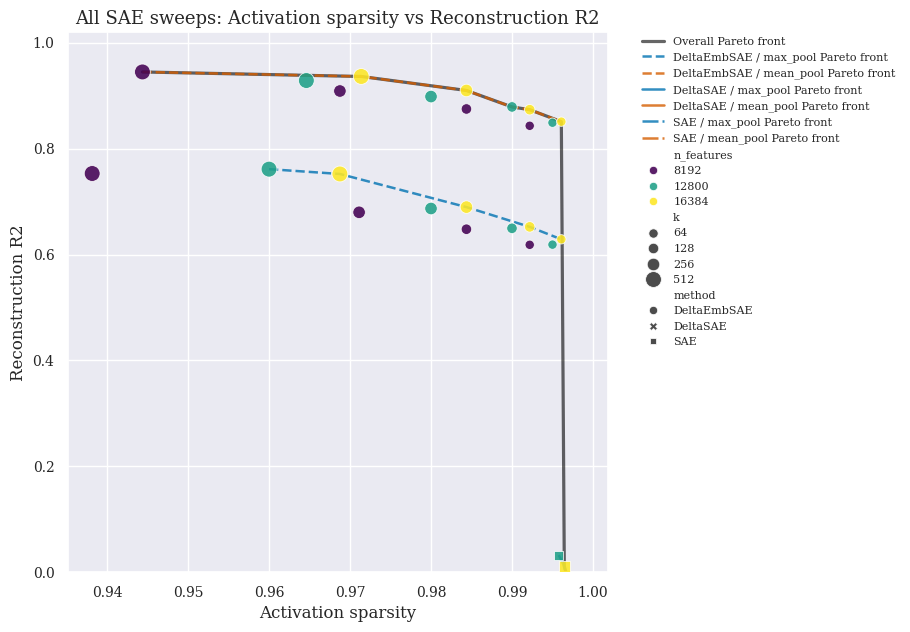

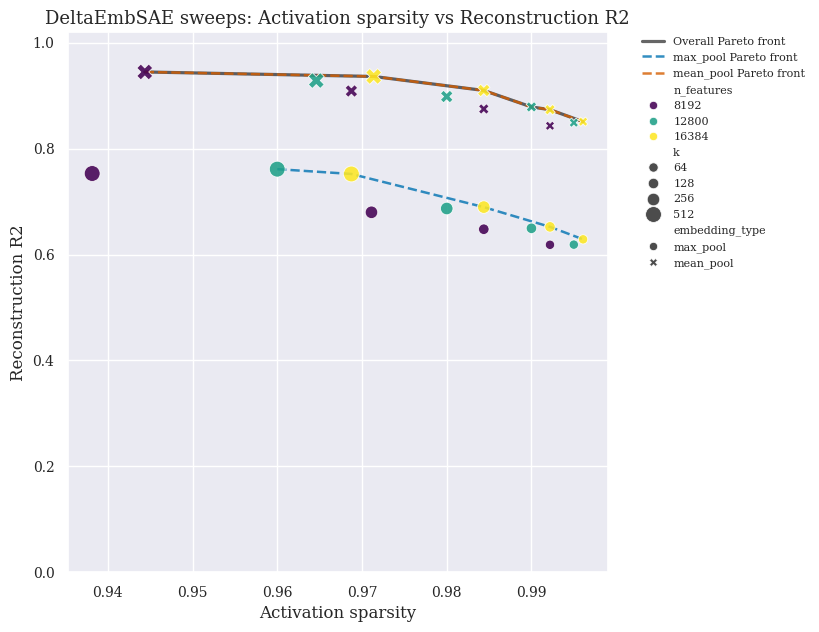

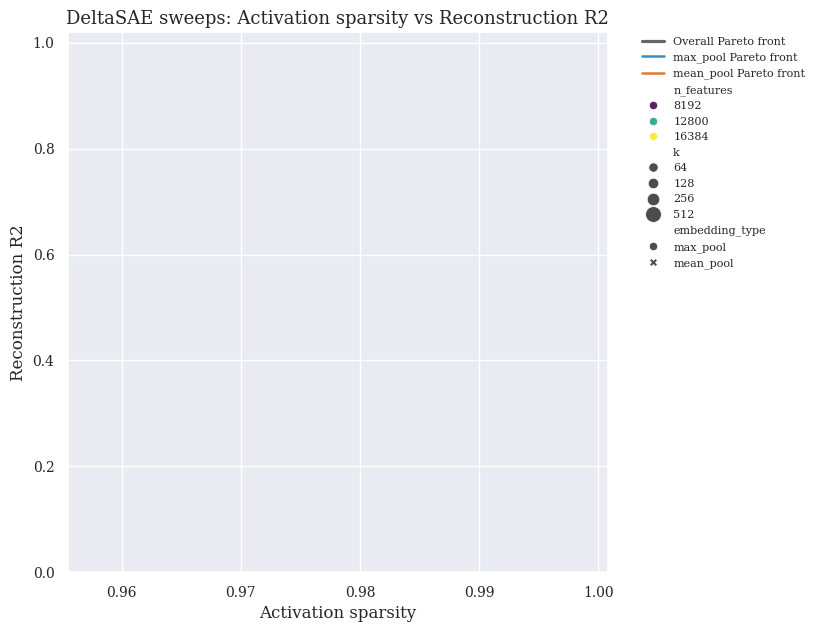

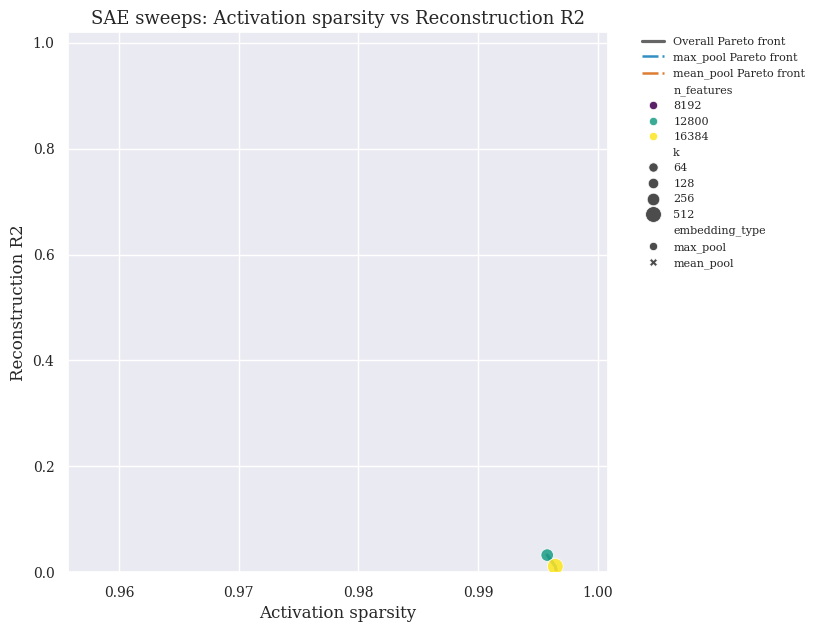

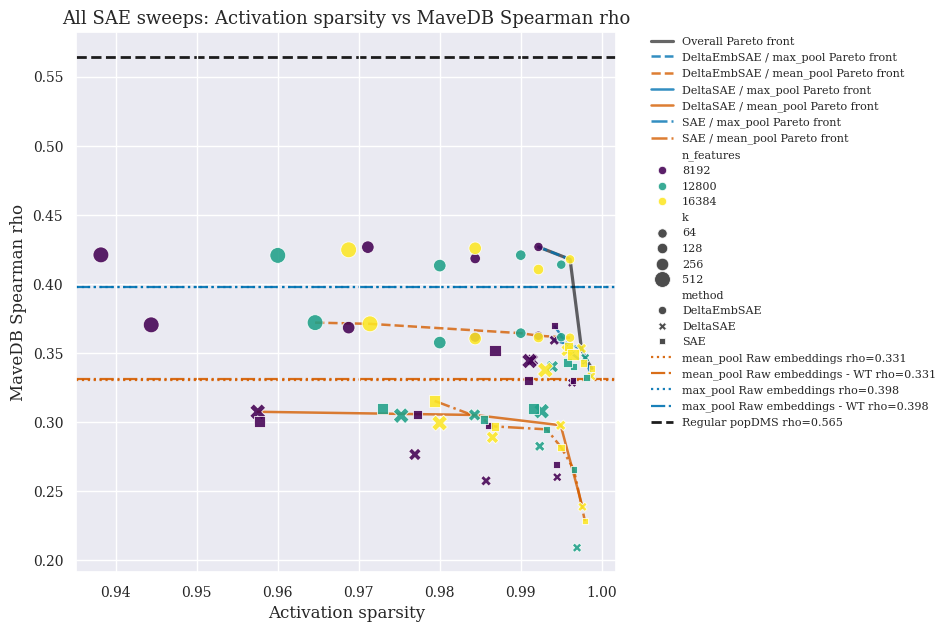

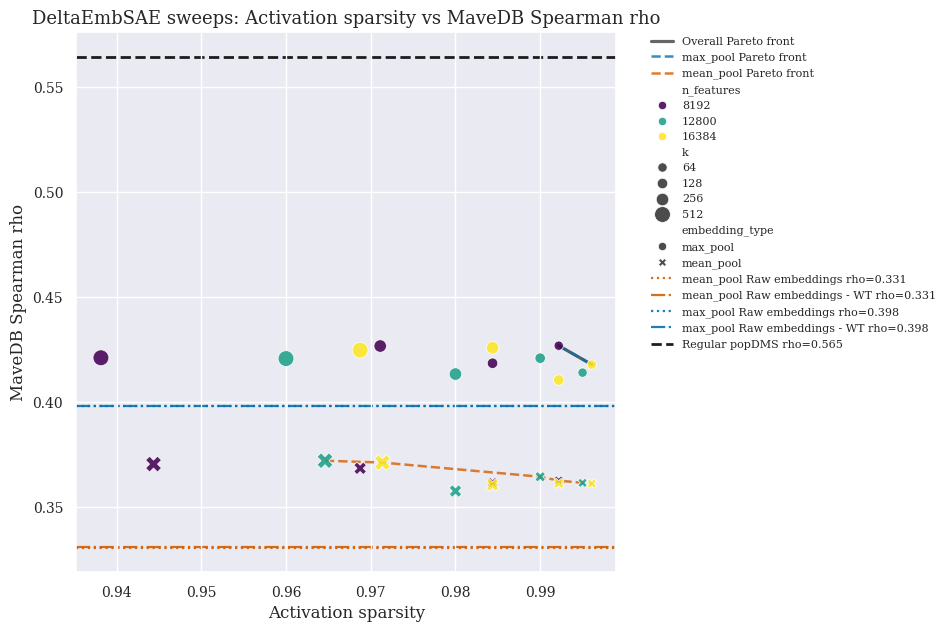

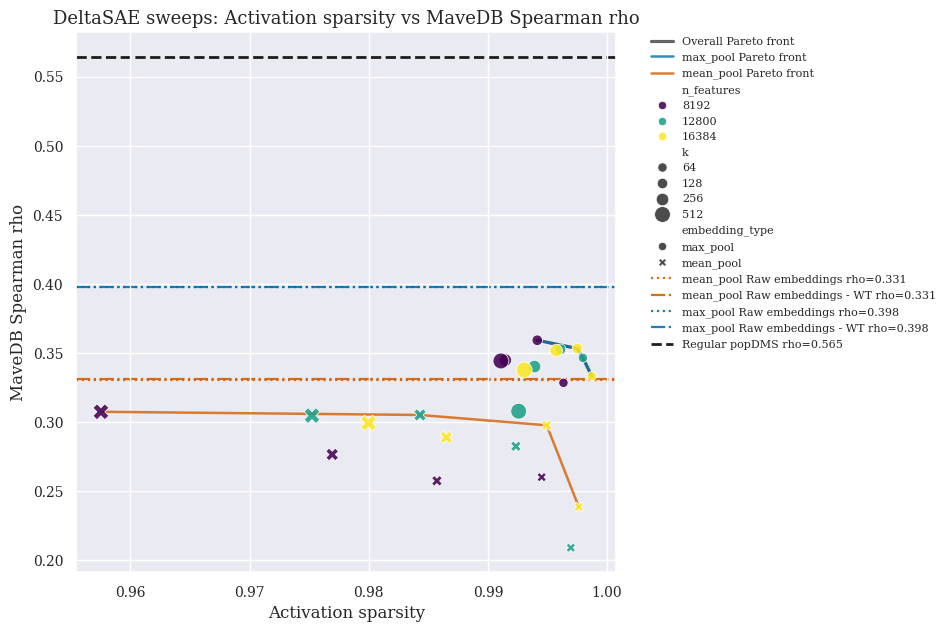

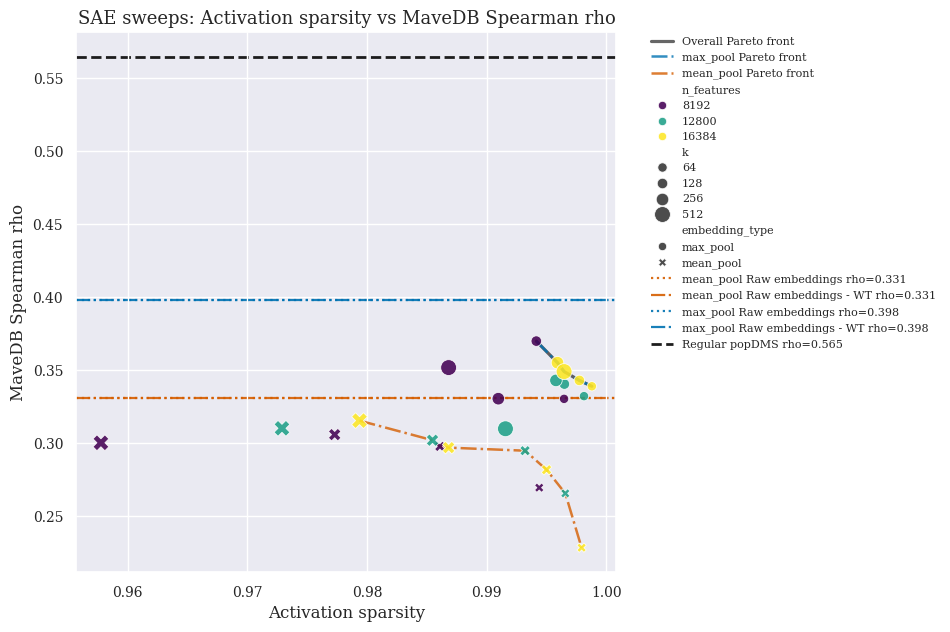

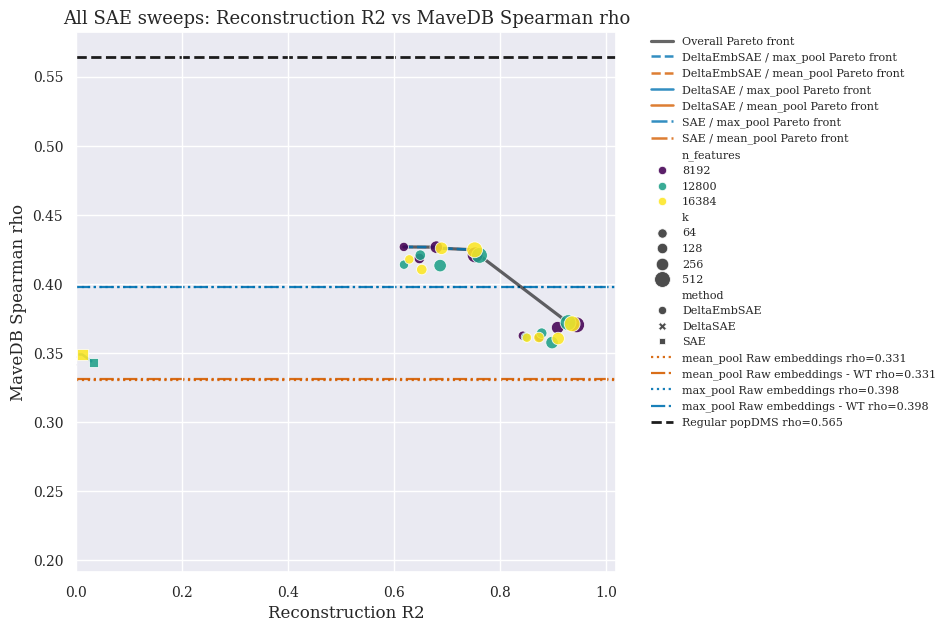

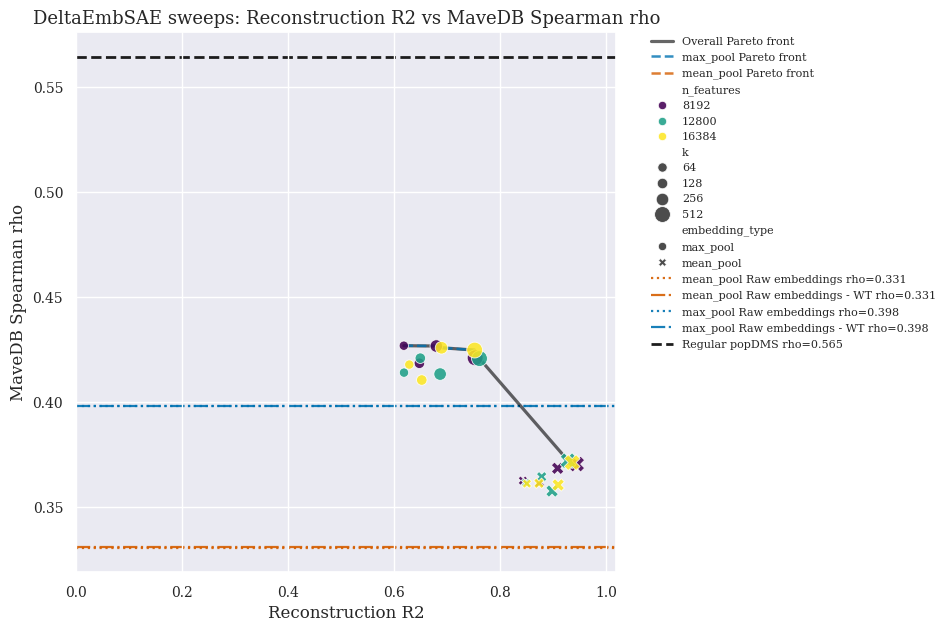

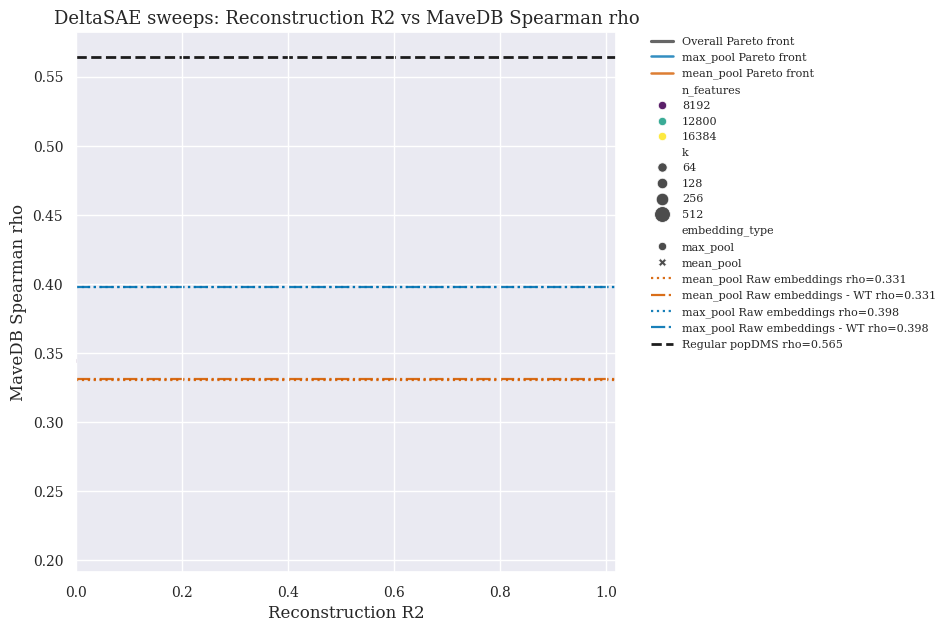

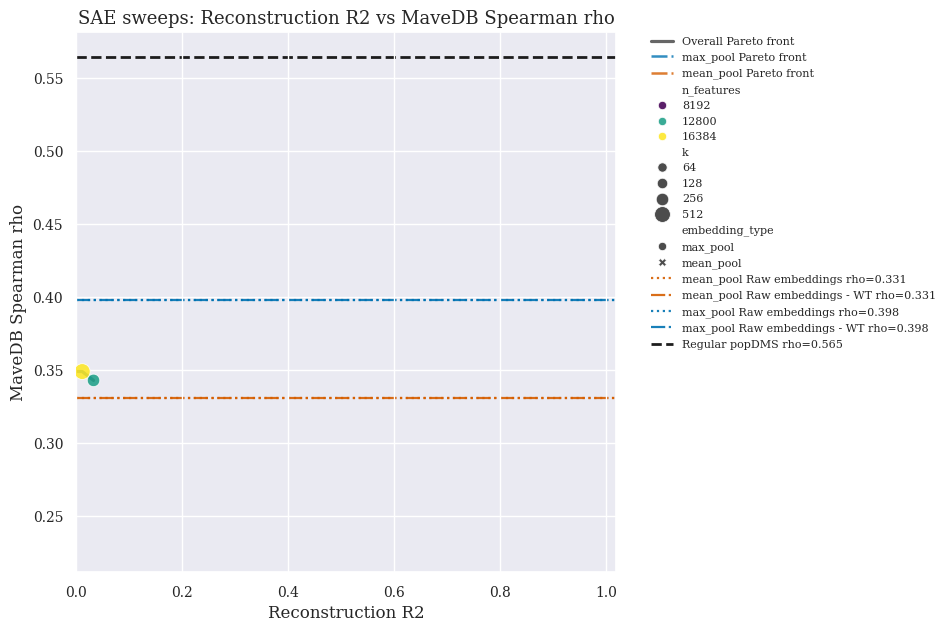

In [15]:
RUN_SAE_SWEEP_PARETO_ANALYSIS = True

if RUN_SAE_SWEEP_PARETO_ANALYSIS:
    SAE_SWEEP_RESULTS_PATHS = _sweep_result_paths()
    existing_sweep_result_paths = [path for path in SAE_SWEEP_RESULTS_PATHS if path.is_file()]
    if not existing_sweep_result_paths:
        print(f"No completed sweep summaries found under {SAE_SWEEP_ANALYSIS_DIR}.")
        print("Submit or run the SAE sweep jobs above, then rerun this cell after sae_sweep_results.csv files are written.")
    else:
        print(f"Loaded {len(existing_sweep_result_paths)} sweep result CSV(s) from {SAE_SWEEP_ANALYSIS_DIR}.")
        sweep_result_frames = []
        for path in existing_sweep_result_paths:
            frame = pd.read_csv(path)
            frame["sweep_results_path"] = str(path)
            sweep_result_frames.append(frame)
        sweep_results = pd.concat(sweep_result_frames, ignore_index=True)
        metric_rows = []
        for _, row in sweep_results.iterrows():
            row_dict = row.to_dict()
            metric_row = dict(row_dict)
            metric_row.update(_reconstruction_metrics(row_dict.get("viz_path", "")))
            rho, n_score = _spearman_rho_for_run(
                row_dict.get("feature_path", ""),
                row_dict.get("inference_path", ""),
                norm_scheme=NORM_SCHEME,
                score_col="score",
            )
            metric_row["spearman_rho"] = rho
            metric_row["n_score_sequences"] = n_score
            metric_rows.append(metric_row)

        sae_sweep_metrics = _ensure_sweep_breakdown_columns(pd.DataFrame(metric_rows))
        sae_sweep_metrics.to_csv(TABLE_DIR / "BRCA1_DeltaSAE_sweep_metrics.csv", index=False)
        benchmark_embedding_types = [
            embedding_type
            for embedding_type in ["mean_pool", "max_pool"]
            if embedding_type in set(sae_sweep_metrics["embedding_type"])
        ]
        raw_embedding_benchmarks = (
            _raw_embedding_benchmark_rows(benchmark_embedding_types, REPRESENTATIVE_LAYER, NORM_SCHEME)
            if RUN_RAW_EMBEDDING_BENCHMARKS and benchmark_embedding_types
            else pd.DataFrame(columns=["benchmark", "embedding_type", "spearman_rho", "n_score_sequences"])
        )
        if RUN_EXACT_POPDMS_BASELINE:
            try:
                raw_embedding_benchmarks = pd.concat(
                    [raw_embedding_benchmarks, pd.DataFrame([_exact_popdms_spearman_benchmark_row()])],
                    ignore_index=True,
                    sort=False,
                )
            except Exception as exc:
                print(f"Skipping regular popDMS Spearman baseline: {exc}")
        raw_embedding_benchmarks.to_csv(TABLE_DIR / "BRCA1_raw_embedding_spearman_benchmarks.csv", index=False)
        display(raw_embedding_benchmarks)
        display(
            sae_sweep_metrics.sort_values("spearman_rho", ascending=False)[[
                "run_label",
                "method",
                "embedding_type",
                "n_features",
                "k",
                "activation_sparsity",
                "reconstruction_r2",
                "spearman_rho",
                "n_active_features",
                "n_score_sequences",
                "method_pool",
            ]].head(20)
        )

        pareto_specs = [
            (
                "activation_sparsity",
                "reconstruction_r2",
                "Activation sparsity",
                "Reconstruction R2",
                FIGURE_DIR / "BRCA1_DeltaSAE_sweep_pareto_sparsity_vs_reconstruction.png",
            ),
            (
                "activation_sparsity",
                "spearman_rho",
                "Activation sparsity",
                "MaveDB Spearman rho",
                FIGURE_DIR / "BRCA1_DeltaSAE_sweep_pareto_sparsity_vs_spearman.png",
            ),
            (
                "reconstruction_r2",
                "spearman_rho",
                "Reconstruction R2",
                "MaveDB Spearman rho",
                FIGURE_DIR / "BRCA1_DeltaSAE_sweep_pareto_reconstruction_vs_spearman.png",
            ),
        ]
        for x_col, y_col, x_label, y_label, output_path in pareto_specs:
            fig = _plot_pareto(
                sae_sweep_metrics,
                x_col,
                y_col,
                x_label,
                y_label,
                output_path,
                title_prefix="All SAE sweeps",
                group_front_col="method_pool",
                style_col="method",
                size_col="k",
                benchmark_df=raw_embedding_benchmarks,
            )
            if fig is not None:
                plt.show()

            for method, method_df in sae_sweep_metrics.groupby("method", sort=True):
                if method == "unknown":
                    continue
                method_output_path = output_path.with_name(f"{output_path.stem}_method_{_plot_suffix(method)}{output_path.suffix}")
                method_fig = _plot_pareto(
                    method_df,
                    x_col,
                    y_col,
                    x_label,
                    y_label,
                    method_output_path,
                    title_prefix=f"{method} sweeps",
                    group_front_col="embedding_type",
                    style_col="embedding_type",
                    size_col="k",
                    benchmark_df=raw_embedding_benchmarks,
                )
                if method_fig is not None:
                    plt.show()

            if PLOT_POOL_ONLY_PARETO:
                for embedding_type, pool_df in sae_sweep_metrics.groupby("embedding_type", sort=True):
                    if embedding_type == "unknown":
                        continue
                    pool_output_path = output_path.with_name(f"{output_path.stem}_pool_{_plot_suffix(embedding_type)}{output_path.suffix}")
                    pool_fig = _plot_pareto(
                        pool_df,
                        x_col,
                        y_col,
                        x_label,
                        y_label,
                        pool_output_path,
                        title_prefix=f"{embedding_type} sweeps",
                        group_front_col="method",
                        style_col="method",
                        size_col="k",
                        benchmark_df=raw_embedding_benchmarks,
                    )
                    if pool_fig is not None:
                        plt.show()

            if PLOT_METHOD_POOL_PARETO:
                for method_pool, group_df in sae_sweep_metrics.groupby("method_pool", sort=True):
                    if "unknown" in method_pool:
                        continue
                    group_output_path = output_path.with_name(f"{output_path.stem}_group_{_plot_suffix(method_pool)}{output_path.suffix}")
                    group_fig = _plot_pareto(
                        group_df,
                        x_col,
                        y_col,
                        x_label,
                        y_label,
                        group_output_path,
                        title_prefix=f"{method_pool} sweeps",
                        group_front_col=None,
                        style_col="k",
                        size_col=None,
                        benchmark_df=raw_embedding_benchmarks,
                    )
                    if group_fig is not None:
                        plt.show()


        def _gamma_regularization_metrics_for_features(
            seq_to_features,
            model_metadata,
            norm_scheme=NORM_SCHEME,
            gamma_values=GAMMA_REGULARIZATION_VALUES,
        ):
            sequence_dataframe, seq_to_features = runner._drop_missing_features(
                runner.sequence_dataframe,
                seq_to_features,
                f"Gamma regularization sweep for {model_metadata.get('model_label', 'model')}",
            )
            runner._require_vector_features(seq_to_features, "Gamma regularization sweep")
            if norm_scheme is not None and norm_scheme != "none":
                seq_ids = list(seq_to_features)
                features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
                features = esmDMS._normalize_features(features, norm_scheme)
                seq_to_features = dict(zip(seq_ids, features))

            gamma_values_out, s_by_gamma, _ = infer_gamma_range(
                sequence_dataframe,
                seq_to_features,
                gamma_values=gamma_values,
            )
            rows = []
            for gamma_idx, gamma in enumerate(gamma_values_out):
                pair_corrs = []
                for rep_i, rep_j in runner._rep_pairs(s_by_gamma.shape[1]):
                    rho = runner._safe_corr(s_by_gamma[gamma_idx, rep_i], s_by_gamma[gamma_idx, rep_j], pearsonr)
                    pair_corrs.append(rho)
                    rows.append({
                        **model_metadata,
                        "gamma": gamma,
                        "rep_i": rep_i + 1,
                        "rep_j": rep_j + 1,
                        "pearson_r": rho,
                    })
                rows.append({
                    **model_metadata,
                    "gamma": gamma,
                    "rep_i": "mean",
                    "rep_j": "mean",
                    "pearson_r": np.nanmean(pair_corrs) if pair_corrs else np.nan,
                })
            return pd.DataFrame(rows)


        def _gamma_model_specs(sweep_metrics, benchmark_embedding_types):
            specs = []
            completed = sweep_metrics.copy()
            completed = completed[completed["feature_path"].map(lambda path: _as_existing_path(path) is not None)].copy()
            for _, row in completed.iterrows():
                row_dict = row.to_dict()
                method = row_dict.get("method", "unknown")
                embedding_type = row_dict.get("embedding_type", "unknown")
                run_label = row_dict.get("run_label", "model")
                specs.append({
                    "model_label": f"{method} {embedding_type} {run_label}",
                    "method": method,
                    "embedding_type": embedding_type,
                    "run_label": run_label,
                    "n_features": row_dict.get("n_features", np.nan),
                    "k": row_dict.get("k", np.nan),
                    "seed": row_dict.get("seed", np.nan),
                    "feature_path": row_dict.get("feature_path", ""),
                    "baseline_kind": "sweep",
                    "is_raw_esm_baseline": False,
                })

            baseline_embedding_types = set(benchmark_embedding_types)
            baseline_embedding_types.update(globals().get("SAE_SWEEP_EMBEDDING_TYPES", []))
            baseline_embedding_types.add(SAE_EMBEDDING_TYPE)
            for embedding_type in sorted(baseline_embedding_types):
                raw_path = runner._embedding_path(REPRESENTATIVE_LAYER, embedding_type)
                if raw_path.is_file():
                    specs.append({
                        "model_label": f"raw ESM {embedding_type}",
                        "method": "none",
                        "embedding_type": embedding_type,
                        "run_label": f"raw_esm_{embedding_type}",
                        "n_features": np.nan,
                        "k": np.nan,
                        "seed": np.nan,
                        "feature_path": str(raw_path),
                        "baseline_kind": "raw",
                        "is_raw_esm_baseline": True,
                    })
                try:
                    delta_features = _raw_delta_embedding_features(REPRESENTATIVE_LAYER, embedding_type)
                except Exception as exc:
                    print(f"Skipping raw ESM - WT gamma sweep for {embedding_type}: {exc}")
                else:
                    specs.append({
                        "model_label": f"raw ESM - WT {embedding_type}",
                        "method": "none_delta_wt",
                        "embedding_type": embedding_type,
                        "run_label": f"raw_esm_delta_wt_{embedding_type}",
                        "n_features": np.nan,
                        "k": np.nan,
                        "seed": np.nan,
                        "feature_path": "",
                        "baseline_kind": "raw_delta_wt",
                        "is_raw_esm_baseline": True,
                    })
            return specs


        def _plot_gamma_regularization_curves(gamma_df, output_path):
            mean_df = gamma_df[gamma_df["rep_i"] == "mean"].copy()
            if mean_df.empty:
                print("No gamma regularization values available to plot.")
                return None
            fig, ax, legend_anchor = _square_axes_figure()
            palette = dict(zip(
                sorted(mean_df["embedding_type"].dropna().unique()),
                sns.color_palette("Set2", n_colors=mean_df["embedding_type"].nunique()),
            ))
            for _, model_df in mean_df.groupby("model_label", sort=False):
                row0 = model_df.iloc[0]
                color = palette.get(row0["embedding_type"], "0.5")
                if bool(row0["is_raw_esm_baseline"]):
                    ax.plot(
                        model_df["gamma"],
                        model_df["pearson_r"],
                        color=color,
                        linewidth=3.0,
                        marker="o",
                        label=row0["model_label"],
                    )
                else:
                    ax.plot(
                        model_df["gamma"],
                        model_df["pearson_r"],
                        color=color,
                        alpha=0.28,
                        linewidth=1.2,
                    )
            ax.set_xscale("log")
            ax.set_ylim(-1, 1)
            ax.set_xlabel("Regularization strength (gamma)")
            ax.set_ylabel("Mean replicate selection-coefficient Pearson r")
            ax.set_title("Gamma regularization across inferred models")
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                _external_legend(fig, ax, legend_anchor, handles, labels)
            fig.savefig(output_path, dpi=FIGURE_DPI)
            return fig


        def _plot_gamma_optimum_summary(gamma_df, output_path):
            mean_df = gamma_df[gamma_df["rep_i"] == "mean"].copy()
            if mean_df.empty:
                return None
            best_idx = mean_df.groupby("model_label")["pearson_r"].idxmax()
            best_df = mean_df.loc[best_idx].copy().sort_values(["method", "embedding_type", "gamma"])
            best_df["model_family"] = np.where(
                best_df["is_raw_esm_baseline"],
                "raw ESM",
                best_df["method"].astype(str) + " k=" + best_df["k"].astype(str) + " nf=" + best_df["n_features"].astype(str),
            )
            ax_size = max(PLOT_AX_SIZE, min(9.0, 0.22 * len(best_df)))
            fig, ax, legend_anchor = _square_axes_figure(ax_size=ax_size)
            sns.scatterplot(
                data=best_df,
                x="gamma",
                y="model_family",
                hue="embedding_type",
                size="pearson_r",
                sizes=(35, 180),
                alpha=0.75,
                ax=ax,
            )
            ax.set_xscale("log")
            ax.set_xlabel("Gamma with highest mean replicate Pearson r")
            ax.set_ylabel("")
            ax.set_title("Best gamma by inferred model")
            _external_legend(fig, ax, legend_anchor)
            fig.savefig(output_path, dpi=FIGURE_DPI)
            return fig


        if PLOT_GAMMA_REGULARIZATION_FOR_ALL_MODELS:
            gamma_rows = []
            for model_spec in _gamma_model_specs(sae_sweep_metrics, benchmark_embedding_types):
                baseline_kind = model_spec.pop("baseline_kind", "sweep")
                if baseline_kind == "raw":
                    seq_to_features = runner.load_embeddings(REPRESENTATIVE_LAYER, model_spec["embedding_type"])
                elif baseline_kind == "raw_delta_wt":
                    seq_to_features = _raw_delta_embedding_features(REPRESENTATIVE_LAYER, model_spec["embedding_type"])
                else:
                    seq_to_features = _load_pickle(model_spec["feature_path"])
                reg_df = _gamma_regularization_metrics_for_features(
                    seq_to_features,
                    model_spec,
                    norm_scheme=NORM_SCHEME,
                    gamma_values=GAMMA_REGULARIZATION_VALUES,
                )
                if not reg_df.empty:
                    gamma_rows.append(reg_df)
            if gamma_rows:
                gamma_regularization_df = pd.concat(gamma_rows, ignore_index=True)
                gamma_regularization_df.to_csv(
                    TABLE_DIR / "BRCA1_all_models_gamma_regularization.csv",
                    index=False,
                )
                display(
                    gamma_regularization_df[gamma_regularization_df["rep_i"] == "mean"]
                    .sort_values("pearson_r", ascending=False)[[
                        "model_label",
                        "method",
                        "embedding_type",
                        "n_features",
                        "k",
                        "gamma",
                        "pearson_r",
                        "is_raw_esm_baseline",
                    ]]
                    .head(20)
                )
                fig = _plot_gamma_regularization_curves(
                    gamma_regularization_df,
                    FIGURE_DIR / "BRCA1_all_models_gamma_regularization_curves.png",
                )
                if fig is not None:
                    plt.show()
                fig = _plot_gamma_optimum_summary(
                    gamma_regularization_df,
                    FIGURE_DIR / "BRCA1_all_models_gamma_regularization_optimum_gamma.png",
                )
                if fig is not None:
                    plt.show()
            else:
                print("No feature files were available for gamma regularization plots.")


## Benign Vs Pathogenic Classification

Use the BRCA1 pathogenicity annotations to evaluate whether inferred fitness separates benign from pathogenic variants. Pathogenic is treated as the positive class and `-fitness` is used as the classifier score.


,model_label,benchmark,embedding_type,auc,n_benign,n_pathogenic,n_variants
1,Raw embeddings max_pool,Raw embeddings,max_pool,0.947794,338,158,496
2,Raw embeddings - WT max_pool,Raw embeddings - WT,max_pool,0.947794,338,158,496
3,Raw embeddings mean_pool,Raw embeddings,mean_pool,0.912104,338,158,496
4,Raw embeddings - WT mean_pool,Raw embeddings - WT,mean_pool,0.912834,338,158,496
0,DMS functional score,DMS functional score,score,0.989461,598,460,1058


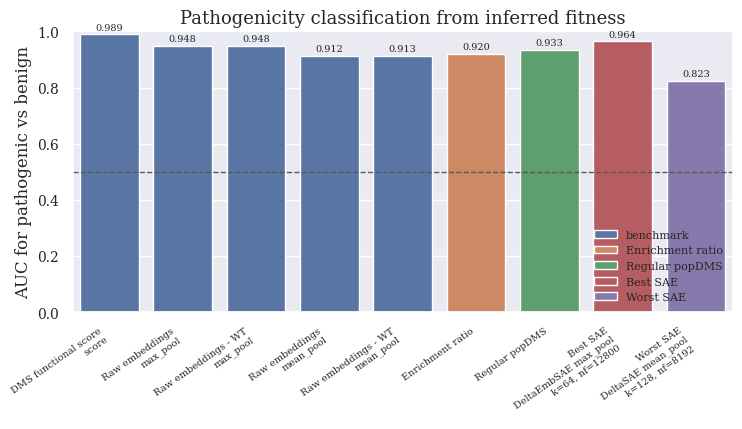

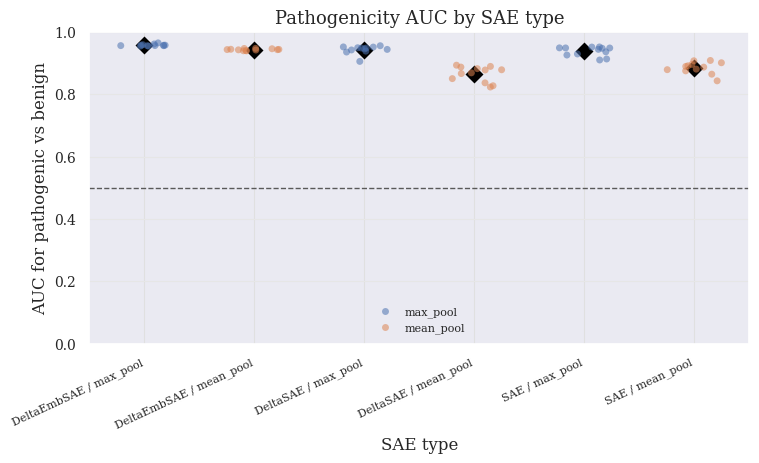

,model_label,model_group,benchmark,method,embedding_type,n_features,k,spearman_rho,n_score_sequences,feature_path,inference_path,method_pool,auc,n_benign,n_pathogenic,n_variants
0,DMS functional score,benchmark,DMS functional score,DMS functional score,score,NaN,NaN,1.000000,3893.0,,,DMS functional score / score,0.989461,598,460,1058
11,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,12800.0,64.0,0.414104,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.964403,338,158,496
13,DeltaEmbSAE_max_pool_batchtopk_k256_nf12800_se...,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,12800.0,256.0,0.413424,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.960864,338,158,496
8,DeltaEmbSAE_max_pool_batchtopk_k128_nf8192_seed42,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,8192.0,128.0,0.418563,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.958524,338,158,496
12,DeltaEmbSAE_max_pool_batchtopk_k128_nf12800_se...,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,12800.0,128.0,0.420982,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.957082,338,158,496
18,DeltaEmbSAE_max_pool_batchtopk_k512_nf16384_se...,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,16384.0,512.0,0.424839,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.957007,338,158,496
15,DeltaEmbSAE_max_pool_batchtopk_k64_nf16384_seed42,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,16384.0,64.0,0.417940,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.956820,338,158,496
16,DeltaEmbSAE_max_pool_batchtopk_k128_nf16384_se...,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,16384.0,128.0,0.410584,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.955771,338,158,496
7,DeltaEmbSAE_max_pool_batchtopk_k64_nf8192_seed42,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,8192.0,64.0,0.426933,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.955640,338,158,496
9,DeltaEmbSAE_max_pool_batchtopk_k256_nf8192_seed42,SAE sweep,SAE sweep,DeltaEmbSAE,max_pool,8192.0,256.0,0.426776,NaN,/Users/dylanwells/popDMS/local_analysis/data/e...,/Users/dylanwells/popDMS/local_analysis/data/e...,DeltaEmbSAE / max_pool,0.955453,338,158,496


In [16]:
RUN_PATHOGENICITY_CLASSIFICATION = True
PATHOGENICITY_LABELS = {"benign", "pathogenic"}
DMS_FUNCTIONAL_SCORE_FITNESS_PATH = TABLE_DIR / "BRCA1_dms_functional_score_fitness_values.csv"
ENRICHMENT_RATIO_FITNESS_PATH = TABLE_DIR / "BRCA1_enrichment_ratio_fitness_values.csv"
import re


def _annotation_map_for_binary_pathogenicity():
    if not hasattr(runner, "primary_key_to_annotation"):
        annotation_df = _load_brca1_pathogenicity_annotations(
            ANNOTATION_PATH,
            BRCA1_INPUT.scores_csv_path,
            BRCA1_INPUT.primary_key,
        )
        runner.annotation_dataframe = annotation_df
        runner.primary_key_to_annotation_identifier = dict(zip(
            annotation_df[BRCA1_INPUT.primary_key],
            annotation_df["annotation_identifier"],
        ))
        runner.primary_key_to_annotation = dict(zip(
            annotation_df[BRCA1_INPUT.primary_key],
            annotation_df["annotation"],
        ))
    return {
        seq_id: annotation
        for seq_id, annotation in runner.primary_key_to_annotation.items()
        if annotation in PATHOGENICITY_LABELS
    }


def _rank_auc(labels, scores):
    labels = np.asarray(labels, dtype=bool)
    scores = np.asarray(scores, dtype=float)
    finite = np.isfinite(scores)
    labels = labels[finite]
    scores = scores[finite]
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        return np.nan
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    return float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def _fitness_for_feature_mapping(seq_to_features, inference_result, annotation_map, norm_scheme=NORM_SCHEME):
    seq_ids = [
        seq_id
        for seq_id, feature in seq_to_features.items()
        if seq_id in annotation_map and feature is not None
    ]
    if not seq_ids:
        return pd.DataFrame(columns=["SequenceIndex", "annotation", "fitness"])
    features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
    if norm_scheme is not None and norm_scheme != "none":
        features = esmDMS._normalize_features(features, norm_scheme)
    fitness = 1.0 + features @ inference_result.s_joint
    return pd.DataFrame({
        "SequenceIndex": seq_ids,
        "annotation": [annotation_map[seq_id] for seq_id in seq_ids],
        "fitness": fitness,
    })


def _classification_metrics_for_fitness(fitness_df):
    binary_df = fitness_df[fitness_df["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["fitness"]).copy()
    if binary_df.empty:
        return {"auc": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    labels = binary_df["annotation"].eq("pathogenic").to_numpy()
    auc = _rank_auc(labels, -binary_df["fitness"].to_numpy(dtype=float))
    return {
        "auc": auc,
        "n_benign": int((~labels).sum()),
        "n_pathogenic": int(labels.sum()),
        "n_variants": int(len(binary_df)),
    }


def _enrichment_ratio_fitness_dataframe(annotation_map=None, pseudocount=0.5):
    counts_df = pd.read_csv(BRCA1_INPUT.mavedb_csv_path).copy()
    primary_key = BRCA1_INPUT.primary_key
    if primary_key not in counts_df.columns:
        raise KeyError(f"Counts table is missing primary key column {primary_key!r}.")
    counts_df["SequenceIndex"] = counts_df[primary_key].astype(str)

    day_count_cols = []
    for column in counts_df.columns:
        match = re.fullmatch(r"count_day(?P<day>\d+)_rep(?P<rep>\d+)", str(column))
        if match:
            day_count_cols.append((int(match.group("day")), int(match.group("rep")), column))
    if not day_count_cols:
        raise ValueError("No count_day<day>_rep<rep> columns were found for enrichment ratio baseline.")

    final_day = max(day for day, _, _ in day_count_cols)
    final_cols = [(rep, column) for day, rep, column in day_count_cols if day == final_day]
    day0_cols = {rep: column for day, rep, column in day_count_cols if day == 0}
    if "count_library" not in counts_df.columns and not day0_cols:
        raise ValueError("Enrichment ratio baseline requires count_library or count_day0_rep<rep> columns.")

    n_rows = len(counts_df)
    replicate_scores = []
    for rep, final_col in sorted(final_cols):
        initial_col = day0_cols.get(rep, "count_library")
        initial_counts = pd.to_numeric(counts_df[initial_col], errors="coerce").fillna(0.0)
        final_counts = pd.to_numeric(counts_df[final_col], errors="coerce").fillna(0.0)
        initial_freq = (initial_counts + pseudocount) / (initial_counts.sum() + pseudocount * n_rows)
        final_freq = (final_counts + pseudocount) / (final_counts.sum() + pseudocount * n_rows)
        replicate_scores.append(np.log2(final_freq / initial_freq))

    enrichment = pd.concat(replicate_scores, axis=1).mean(axis=1)
    fitness_df = pd.DataFrame({
        "SequenceIndex": counts_df["SequenceIndex"],
        "fitness": enrichment,
    })
    if annotation_map is not None:
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df


def _enrichment_ratio_classification_specs(annotation_map):
    try:
        fitness_df = _enrichment_ratio_fitness_dataframe(annotation_map)
        fitness_df.to_csv(ENRICHMENT_RATIO_FITNESS_PATH, index=False)
        spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    except Exception as exc:
        print(f"Skipping enrichment ratio pathogenicity classification: {exc}")
        return []
    return [{
        "model_label": "Enrichment ratio",
        "model_group": "Enrichment ratio",
        "benchmark": "Enrichment ratio",
        "method": "enrichment ratio",
        "embedding_type": "day11 / day0 counts",
        "n_features": np.nan,
        "k": np.nan,
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "feature_path": "",
        "inference_path": "",
        "method_pool": "enrichment ratio",
        "fitness_df": fitness_df,
    }]


def _dms_functional_score_fitness_dataframe(annotation_map, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    if score_col not in runner.scores_dataframe.columns:
        raise KeyError(f"Score column {score_col!r} is not present in scores_dataframe.")
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    fitness_df = score_df.rename(columns={score_col: "fitness"})
    fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df


def _dms_functional_score_classification_specs(annotation_map, score_col="score"):
    try:
        fitness_df = _dms_functional_score_fitness_dataframe(annotation_map, score_col=score_col)
        fitness_df.to_csv(DMS_FUNCTIONAL_SCORE_FITNESS_PATH, index=False)
    except Exception as exc:
        print(f"Skipping DMS functional score pathogenicity classification: {exc}")
        return []
    return [{
        "model_label": "DMS functional score",
        "model_group": "benchmark",
        "benchmark": "DMS functional score",
        "method": "DMS functional score",
        "embedding_type": score_col,
        "n_features": np.nan,
        "k": np.nan,
        "spearman_rho": 1.0,
        "n_score_sequences": int(fitness_df["fitness"].notna().sum()),
        "feature_path": "",
        "inference_path": "",
        "method_pool": "DMS functional score",
        "fitness_df": fitness_df,
    }]


def _classification_row(model_spec, annotation_map):
    if "fitness_df" in model_spec:
        fitness_df = model_spec["fitness_df"].copy()
    else:
        seq_to_features = model_spec["seq_to_features"]
        inference_result = model_spec["inference_result"]
        fitness_df = _fitness_for_feature_mapping(seq_to_features, inference_result, annotation_map)
    metrics = _classification_metrics_for_fitness(fitness_df)
    return {
        **{key: value for key, value in model_spec.items() if key not in {"seq_to_features", "inference_result", "fitness_df"}},
        **metrics,
        "fitness_df": fitness_df,
    }


def _sweep_metrics_for_classification():
    if "sae_sweep_metrics" in globals():
        return sae_sweep_metrics.copy()
    metrics_path = TABLE_DIR / "BRCA1_DeltaSAE_sweep_metrics.csv"
    if metrics_path.is_file():
        return pd.read_csv(metrics_path)
    result_paths = [path for path in _sweep_result_paths() if path.is_file()]
    if not result_paths:
        return pd.DataFrame()
    return pd.concat([pd.read_csv(path) for path in result_paths], ignore_index=True)


def _raw_classification_specs(annotation_map):
    specs = []
    embedding_types = sorted(
        set(globals().get("SAE_SWEEP_EMBEDDING_TYPES", [])) | {SAE_EMBEDDING_TYPE, "mean_pool", "max_pool"}
    )
    for embedding_type in embedding_types:
        try:
            raw_features = runner.load_embeddings(REPRESENTATIVE_LAYER, embedding_type)
            raw_inference = runner.run_feature_inference(
                layer=REPRESENTATIVE_LAYER,
                abstraction_method="none",
                abstraction_params={"norm_scheme": NORM_SCHEME},
                embedding_type=embedding_type,
            )
            specs.append({
                "model_label": f"Raw embeddings {embedding_type}",
                "model_group": "benchmark",
                "benchmark": "Raw embeddings",
                "method": "raw ESM",
                "embedding_type": embedding_type,
                "seq_to_features": raw_features,
                "inference_result": raw_inference,
            })

            delta_features, delta_inference, _, _ = _raw_delta_embedding_inference(
                REPRESENTATIVE_LAYER,
                embedding_type,
                NORM_SCHEME,
            )
            specs.append({
                "model_label": f"Raw embeddings - WT {embedding_type}",
                "model_group": "benchmark",
                "benchmark": "Raw embeddings - WT",
                "method": "raw ESM - WT",
                "embedding_type": embedding_type,
                "seq_to_features": delta_features,
                "inference_result": delta_inference,
            })
        except Exception as exc:
            print(f"Skipping {embedding_type} raw benchmark classification: {exc}")
    return specs


def _exact_popdms_classification_specs(annotation_map):
    if not globals().get("RUN_EXACT_POPDMS_BASELINE", True):
        return []
    try:
        selection_df = _exact_popdms_selection_coefficients(
            force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE,
        )
        fitness_df = _exact_popdms_fitness_dataframe(selection_df, annotation_map)
        fitness_df.to_csv(EXACT_POPDMS_FITNESS_PATH, index=False)
        spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    except Exception as exc:
        print(f"Skipping regular popDMS pathogenicity classification: {exc}")
        return []
    return [{
        "model_label": "Regular popDMS",
        "model_group": "Regular popDMS",
        "benchmark": "Regular popDMS",
        "method": "regular popDMS",
        "embedding_type": "amino-acid haplotype frequencies",
        "n_features": int(len(selection_df)),
        "k": np.nan,
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "feature_path": "",
        "inference_path": str(EXACT_POPDMS_SELECTION_PATH),
        "method_pool": "regular popDMS",
        "fitness_df": fitness_df,
    }]


def _sae_classification_specs(sweep_df):
    specs = []
    if sweep_df.empty:
        return specs
    ok_df = sweep_df[sweep_df.get("status", "ok").eq("ok")].copy() if "status" in sweep_df.columns else sweep_df.copy()
    for _, row in ok_df.iterrows():
        feature_path = _as_existing_path(row.get("feature_path"))
        inference_path = _as_existing_path(row.get("inference_path"))
        if feature_path is None or inference_path is None:
            continue
        specs.append({
            "model_label": row.get("run_label", feature_path.parent.name),
            "model_group": "SAE sweep",
            "benchmark": "SAE sweep",
            "method": row.get("method", "unknown"),
            "embedding_type": row.get("embedding_type", "unknown"),
            "n_features": row.get("n_features", np.nan),
            "k": row.get("k", np.nan),
            "spearman_rho": row.get("spearman_rho", np.nan),
            "feature_path": str(feature_path),
            "inference_path": str(inference_path),
            "seq_to_features": _load_pickle(feature_path),
            "inference_result": _load_pickle(inference_path),
        })
    return specs


if RUN_PATHOGENICITY_CLASSIFICATION:
    annotation_map = _annotation_map_for_binary_pathogenicity()
    sweep_df = _ensure_sweep_breakdown_columns(_sweep_metrics_for_classification())
    model_specs = (
        _dms_functional_score_classification_specs(annotation_map)
        + _raw_classification_specs(annotation_map)
        + _enrichment_ratio_classification_specs(annotation_map)
        + _exact_popdms_classification_specs(annotation_map)
        + _sae_classification_specs(sweep_df)
    )

    classification_rows = []
    fitness_frames = []
    for model_spec in model_specs:
        row = _classification_row(model_spec, annotation_map)
        fitness_df = row.pop("fitness_df")
        classification_rows.append(row)
        if not fitness_df.empty:
            fitness_frames.append(fitness_df.assign(model_label=row["model_label"]))

    pathogenicity_auc_df = pd.DataFrame(classification_rows)
    if not pathogenicity_auc_df.empty:
        pathogenicity_auc_df["method_pool"] = (
            pathogenicity_auc_df["method"].astype(str) + " / " + pathogenicity_auc_df["embedding_type"].astype(str)
        )
        pathogenicity_auc_df.to_csv(TABLE_DIR / "BRCA1_pathogenicity_auc_metrics.csv", index=False)
        if fitness_frames:
            pd.concat(fitness_frames, ignore_index=True).to_csv(
                TABLE_DIR / "BRCA1_pathogenicity_fitness_values.csv",
                index=False,
            )

        benchmark_auc_df = pathogenicity_auc_df[pathogenicity_auc_df["model_group"].eq("benchmark")].copy()
        enrichment_auc_df = pathogenicity_auc_df[pathogenicity_auc_df["model_group"].eq("Enrichment ratio")].copy()
        popdms_auc_df = pathogenicity_auc_df[pathogenicity_auc_df["model_group"].eq("Regular popDMS")].copy()
        sae_auc_df = pathogenicity_auc_df[pathogenicity_auc_df["model_group"].eq("SAE sweep")].copy()
        selected_auc_rows = [benchmark_auc_df, enrichment_auc_df, popdms_auc_df]
        finite_sae_auc_df = sae_auc_df[np.isfinite(sae_auc_df["auc"])].copy()
        if not finite_sae_auc_df.empty:
            selected_auc_rows.extend([
                finite_sae_auc_df.loc[[finite_sae_auc_df["auc"].idxmax()]].assign(model_group="Best SAE"),
                finite_sae_auc_df.loc[[finite_sae_auc_df["auc"].idxmin()]].assign(model_group="Worst SAE"),
            ])
        selected_auc_df = pd.concat(selected_auc_rows, ignore_index=True)

        def _pathogenicity_plot_label(row):
            if row["model_group"] == "benchmark":
                return f"{row['benchmark']}\n{row['embedding_type']}"
            if row["model_group"] == "Enrichment ratio":
                return "Enrichment ratio"
            if row["model_group"] == "Regular popDMS":
                return "Regular popDMS"
            k_label = "NA" if pd.isna(row.get("k")) else f"{int(row['k'])}"
            n_features_label = "NA" if pd.isna(row.get("n_features")) else f"{int(row['n_features'])}"
            return f"{row['model_group']}\n{row['method']} {row['embedding_type']}\nk={k_label}, nf={n_features_label}"

        selected_auc_df["plot_label"] = selected_auc_df.apply(_pathogenicity_plot_label, axis=1)

        display(
            benchmark_auc_df.sort_values(["embedding_type", "benchmark"])[[
                "model_label",
                "benchmark",
                "embedding_type",
                "auc",
                "n_benign",
                "n_pathogenic",
                "n_variants",
            ]]
        )

        fig, ax = plt.subplots(figsize=(max(7.5, 0.60 * len(selected_auc_df)), 5.2))
        sns.barplot(
            data=selected_auc_df,
            x="plot_label",
            y="auc",
            hue="model_group",
            dodge=False,
            ax=ax,
        )
        ax.axhline(0.5, color="0.35", linestyle="--", linewidth=1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("")
        ax.set_ylabel("AUC for pathogenic vs benign")
        ax.set_title("Pathogenicity classification from inferred fitness")
        ax.tick_params(axis="x", rotation=35, labelsize=7)
        for label in ax.get_xticklabels():
            label.set_ha("right")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=2, fontsize=7)
        ax.legend(frameon=False, loc="lower right")
        fig.subplots_adjust(bottom=0.36, left=0.10, right=0.98, top=0.90)
        fig.savefig(FIGURE_DIR / "BRCA1_pathogenicity_auc_selected_models.png", dpi=FIGURE_DPI)
        plt.show()

        if not sae_auc_df.empty:
            method_order = [
                method_pool
                for method_pool in sorted(sae_auc_df["method_pool"].dropna().unique())
            ]
            fig, ax = plt.subplots(figsize=(max(7.5, 0.80 * len(method_order)), 5.2))
            sns.stripplot(
                data=sae_auc_df,
                x="method_pool",
                y="auc",
                hue="embedding_type",
                order=method_order,
                jitter=0.25,
                alpha=0.55,
                size=5,
                ax=ax,
            )
            sns.pointplot(
                data=sae_auc_df,
                x="method_pool",
                y="auc",
                order=method_order,
                estimator="mean",
                errorbar=None,
                color="black",
                markers="D",
                linestyles="none",
                ax=ax,
            )
            ax.axhline(0.5, color="0.35", linestyle="--", linewidth=1)
            for x_pos in range(len(method_order)):
                ax.axvline(x_pos, color="0.88", linewidth=0.8, zorder=0)
            ax.set_axisbelow(True)
            ax.grid(axis="y", color="0.90", linewidth=0.8)
            ax.set_ylim(0, 1)
            ax.set_xlabel("SAE type")
            ax.set_ylabel("AUC for pathogenic vs benign")
            ax.set_title("Pathogenicity AUC by SAE type")
            ax.tick_params(axis="x", rotation=25, labelsize=8)
            for label in ax.get_xticklabels():
                label.set_ha("right")
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles[:sae_auc_df["embedding_type"].nunique()], labels[:sae_auc_df["embedding_type"].nunique()], frameon=False)
            fig.subplots_adjust(bottom=0.30, left=0.10, right=0.98, top=0.90)
            fig.savefig(FIGURE_DIR / "BRCA1_pathogenicity_auc_by_sae_type.png", dpi=FIGURE_DPI)
            plt.show()

        display(pathogenicity_auc_df.sort_values("auc", ascending=False).head(20))
    else:
        print("No models with available feature and inference files were found for pathogenicity classification.")


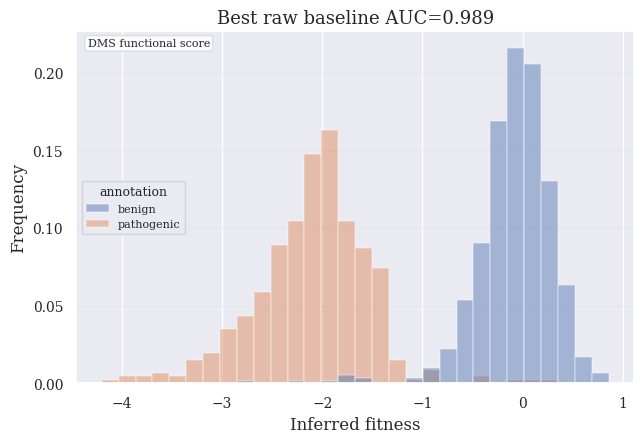

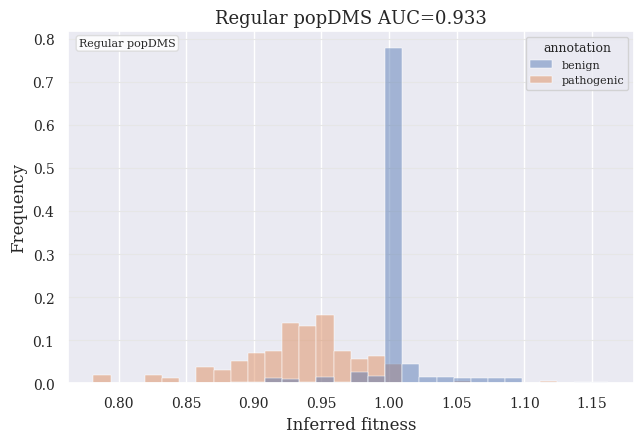

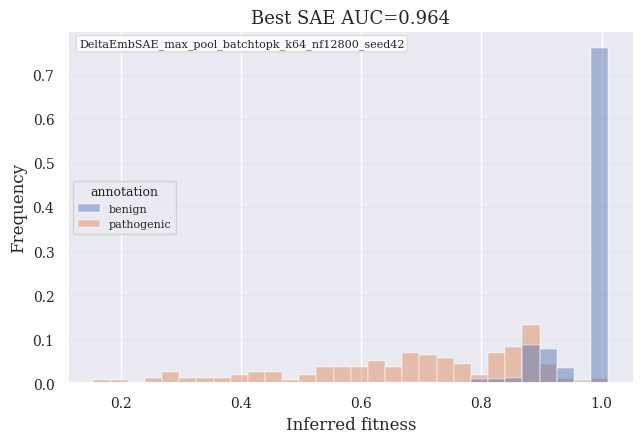

,model_group,model_label,method,embedding_type,auc,n_benign,n_pathogenic,n_variants
0,benchmark,DMS functional score,DMS functional score,score,0.989461,598,460,1058
6,Regular popDMS,Regular popDMS,regular popDMS,amino-acid haplotype frequencies,0.933076,338,158,496
11,SAE sweep,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,DeltaEmbSAE,max_pool,0.964403,338,158,496


In [17]:
PLOT_BEST_PATHOGENICITY_FITNESS_DISTRIBUTIONS = True


def _fitness_dataframe_for_auc_row(row, annotation_map):
    if row["benchmark"] == "Regular popDMS":
        selection_df = _exact_popdms_selection_coefficients(
            force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE,
        )
        return _exact_popdms_fitness_dataframe(selection_df, annotation_map)
    features_and_inference = _features_and_inference_for_auc_row(row)
    if isinstance(features_and_inference, pd.DataFrame):
        return features_and_inference
    seq_to_features, inference_result = features_and_inference
    return _fitness_for_feature_mapping(seq_to_features, inference_result, annotation_map)


def _features_and_inference_for_auc_row(row):
    if row["model_group"] == "SAE sweep":
        return _load_pickle(row["feature_path"]), _load_pickle(row["inference_path"])
    if row["benchmark"] == "DMS functional score":
        return _dms_functional_score_fitness_dataframe(annotation_map, score_col=row.get("embedding_type", "score"))
    if row["benchmark"] == "Raw embeddings":
        seq_to_features = runner.load_embeddings(REPRESENTATIVE_LAYER, row["embedding_type"])
        inference_result = runner.run_feature_inference(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method="none",
            abstraction_params={"norm_scheme": NORM_SCHEME},
            embedding_type=row["embedding_type"],
        )
        return seq_to_features, inference_result
    if row["benchmark"] == "Raw embeddings - WT":
        seq_to_features, inference_result, _, _ = _raw_delta_embedding_inference(
            REPRESENTATIVE_LAYER,
            row["embedding_type"],
            NORM_SCHEME,
        )
        return seq_to_features, inference_result
    raise ValueError(f"Unsupported benchmark row: {row.to_dict()}")


def _mavedb_functional_score_dataframe(annotation_map, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    if score_col not in runner.scores_dataframe.columns:
        raise KeyError(f"MaveDB score column {score_col!r} is missing from scores_dataframe.")
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["functional_score"] = pd.to_numeric(score_df[score_col], errors="coerce")
    score_df["annotation"] = score_df["SequenceIndex"].astype(str).map(annotation_map)
    score_df = score_df[
        score_df["annotation"].isin(PATHOGENICITY_LABELS)
        & np.isfinite(score_df["functional_score"])
    ].copy()
    return score_df[["SequenceIndex", "annotation", "functional_score"]]


if PLOT_BEST_PATHOGENICITY_FITNESS_DISTRIBUTIONS:
    if "pathogenicity_auc_df" not in globals() or pathogenicity_auc_df.empty:
        pathogenicity_auc_df = pd.read_csv(TABLE_DIR / "BRCA1_pathogenicity_auc_metrics.csv")
    annotation_map = _annotation_map_for_binary_pathogenicity()
    finite_auc_df = pathogenicity_auc_df[np.isfinite(pathogenicity_auc_df["auc"])].copy()
    if finite_auc_df.empty:
        raise ValueError("No finite pathogenicity AUC rows are available for plotting.")

    benchmark_rows = finite_auc_df[finite_auc_df["model_group"].eq("benchmark")].copy()
    sae_rows = finite_auc_df[finite_auc_df["model_group"].eq("SAE sweep")].copy()
    popdms_rows = finite_auc_df[finite_auc_df["model_group"].eq("Regular popDMS")].copy()

    best_baseline_row = benchmark_rows.sort_values("auc", ascending=False).iloc[0] if not benchmark_rows.empty else None
    best_sae_row = sae_rows.sort_values("auc", ascending=False).iloc[0] if not sae_rows.empty else None
    popdms_row = popdms_rows.sort_values("auc", ascending=False).iloc[0] if not popdms_rows.empty else None

    distribution_frames = []
    distribution_specs = []
    if best_baseline_row is not None:
        distribution_specs.append((best_baseline_row, "Best raw baseline"))
    if popdms_row is not None:
        distribution_specs.append((popdms_row, "Regular popDMS"))
    if best_sae_row is not None:
        distribution_specs.append((best_sae_row, "Best SAE"))
    else:
        print("No SAE sweep AUC row found; rerun the SAE sweep Pareto/classification cells after sweep summaries are loaded.")

    for row, display_label in distribution_specs:
        try:
            fitness_df = _fitness_dataframe_for_auc_row(row, annotation_map)
        except FileNotFoundError as exc:
            print(f"Skipping {display_label} fitness distribution: {exc}")
            continue
        if fitness_df.empty or "annotation" not in fitness_df.columns:
            print(f"Skipping {display_label} fitness distribution: no annotated fitness rows.")
            continue
        fitness_df = fitness_df[fitness_df["annotation"].isin(PATHOGENICITY_LABELS)].copy()
        if fitness_df.empty:
            print(f"Skipping {display_label} fitness distribution: no benign/pathogenic rows.")
            continue
        fitness_df["model"] = display_label
        fitness_df["model_label"] = row["model_label"]
        fitness_df["auc"] = row["auc"]
        distribution_frames.append(fitness_df)

    if not distribution_frames:
        raise ValueError("No pathogenicity fitness distributions could be built from the available AUC rows.")
    best_pathogenicity_fitness_df = pd.concat(distribution_frames, ignore_index=True)
    best_pathogenicity_fitness_df.to_csv(
        TABLE_DIR / "BRCA1_best_pathogenicity_model_fitness_distributions.csv",
        index=False,
    )

    model_order = ["Best raw baseline", "Regular popDMS", "Best SAE"]
    output_names = {
        "Best raw baseline": "BRCA1_best_raw_baseline_pathogenicity_fitness_frequency.png",
        "Regular popDMS": "BRCA1_regular_popDMS_pathogenicity_fitness_frequency.png",
        "Best SAE": "BRCA1_best_sae_pathogenicity_fitness_frequency.png",
    }
    for model in model_order:
        model_df = best_pathogenicity_fitness_df[best_pathogenicity_fitness_df["model"].eq(model)]
        if model_df.empty:
            continue
        row = model_df.iloc[0]
        fig, ax = plt.subplots(figsize=(6.6, 4.6))
        sns.histplot(
            data=model_df,
            x="fitness",
            hue="annotation",
            hue_order=["benign", "pathogenic"],
            multiple="layer",
            bins=30,
            stat="probability",
            common_norm=False,
            alpha=0.45,
            edgecolor="white",
            linewidth=0.35,
            ax=ax,
        )
        ax.set_title(f"{model} AUC={row['auc']:.3f}")
        ax.set_xlabel("Inferred fitness")
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", color="0.90", linewidth=0.8)
        ax.text(
            0.02,
            0.98,
            str(row["model_label"]),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.85", "alpha": 0.85},
        )
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / output_names[model], dpi=FIGURE_DPI)
        plt.show()

    mavedb_functional_score_df = _mavedb_functional_score_dataframe(annotation_map)
    mavedb_functional_score_df.to_csv(
        TABLE_DIR / "BRCA1_mavedb_functional_score_pathogenicity_distributions.csv",
        index=False,
    )
    if not mavedb_functional_score_df.empty:
        mavedb_auc_metrics = _classification_metrics_for_fitness(
            mavedb_functional_score_df.rename(columns={"functional_score": "fitness"})
        )
        mavedb_auc = mavedb_auc_metrics["auc"]
        auc_label = f"AUC={mavedb_auc:.3f}" if np.isfinite(mavedb_auc) else "AUC unavailable"
        fig, ax = plt.subplots(figsize=(6.6, 4.6))
        sns.histplot(
            data=mavedb_functional_score_df,
            x="functional_score",
            hue="annotation",
            hue_order=["benign", "pathogenic"],
            multiple="layer",
            bins=30,
            stat="probability",
            common_norm=False,
            alpha=0.45,
            edgecolor="white",
            linewidth=0.35,
            ax=ax,
        )
        ax.set_title(f"MaveDB functional score by ClinVar class ({auc_label})")
        ax.set_xlabel("MaveDB functional score")
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", color="0.90", linewidth=0.8)
        fig.tight_layout()
        fig.savefig(
            FIGURE_DIR / "BRCA1_mavedb_functional_score_pathogenicity_frequency.png",
            dpi=FIGURE_DPI,
        )
        plt.show()

    display(
        pathogenicity_auc_df[
            pathogenicity_auc_df["model_label"].isin([
                label for label in [
                    best_baseline_row["model_label"],
                    popdms_row["model_label"] if popdms_row is not None else None,
                    best_sae_row["model_label"] if best_sae_row is not None else None,
                ]
                if label is not None
            ])
        ][[
            "model_group",
            "model_label",
            "method",
            "embedding_type",
            "auc",
            "n_benign",
            "n_pathogenic",
            "n_variants",
        ]]
    )


## MaveDB Spearman Vs ClinVar AUC

Compare each inferred model and baseline by MaveDB functional-score Spearman rho and ClinVar pathogenic-vs-benign AUC. The regular popDMS baseline uses the cached exact-popDMS selection coefficients from the cache-generation cell above, then scores variants as `1 + sum_i x_i s_i` from the inferred joint selection coefficients.

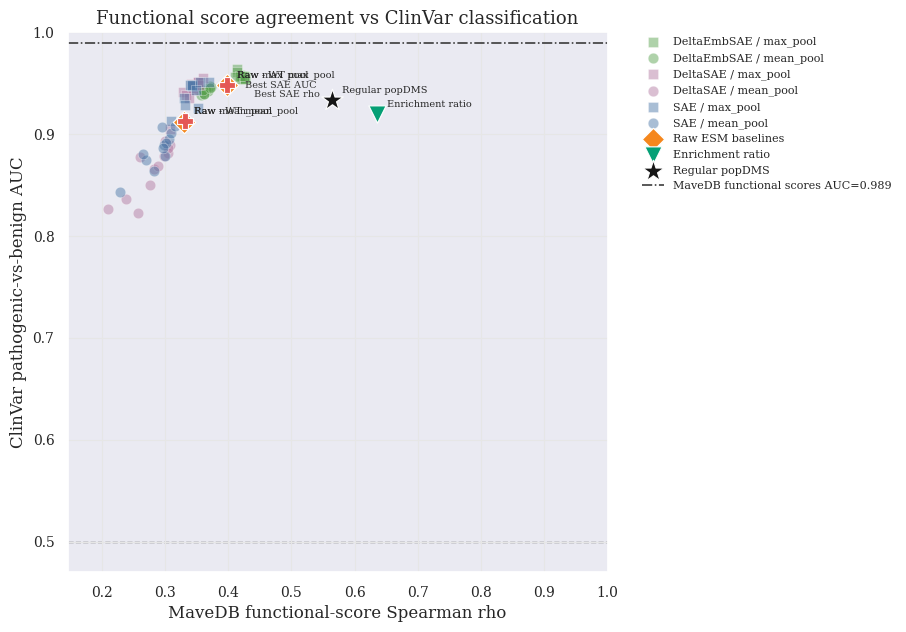

,review_filter,best_esm_baseline_auc,best_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,all binary annotations,0.948,0.964,0.989,0.933,598,460


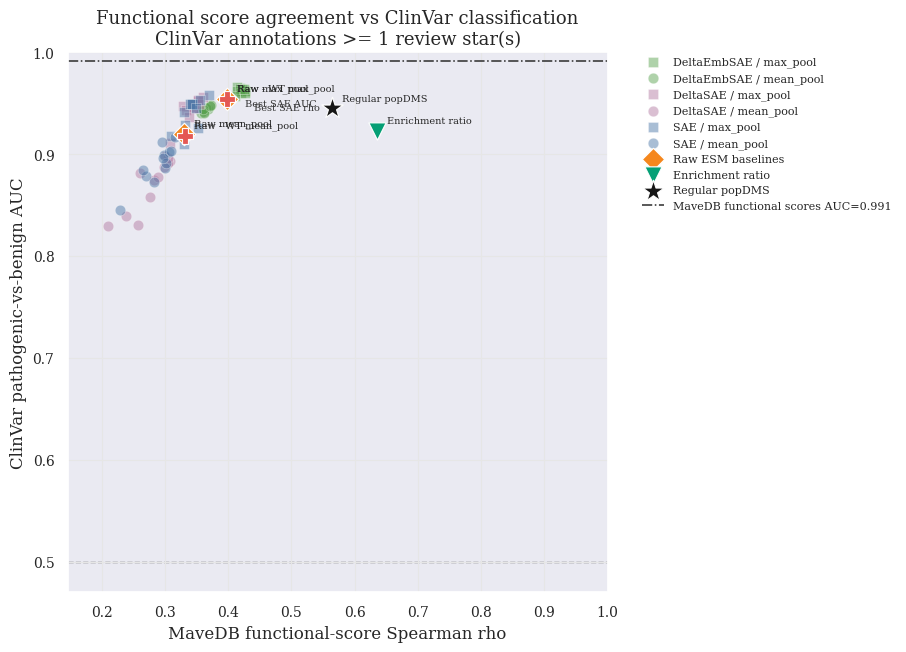

,review_filter,best_esm_baseline_auc,best_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 1 star(s),0.954,0.966,0.991,0.945,595,452


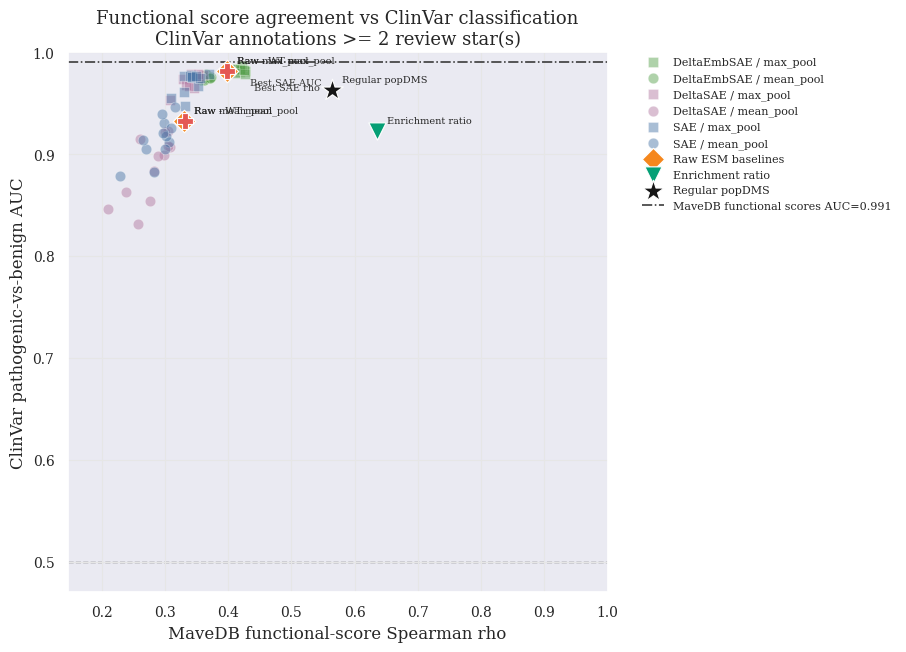

,review_filter,best_esm_baseline_auc,best_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 2 star(s),0.982,0.986,0.991,0.963,286,348


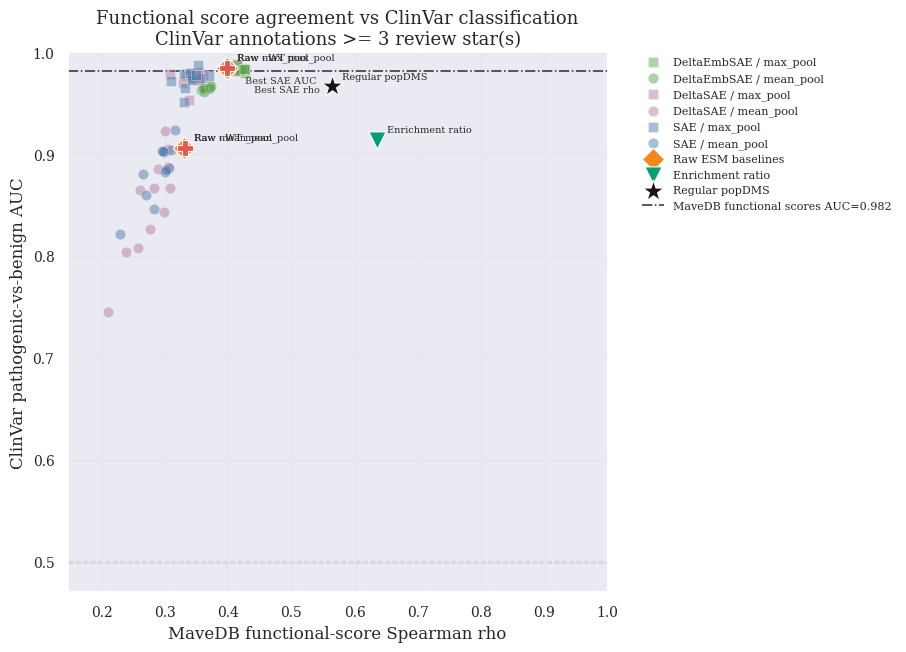

,review_filter,best_esm_baseline_auc,best_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 3 star(s),0.984,0.988,0.982,0.966,107,159


No finite Spearman/AUC pairs were available to plot.


,min_review_stars,dataset,plot_group,model_label,method,embedding_type,spearman_rho,auc,n_score_sequences,n_benign,n_pathogenic,n_variants
77,1,BRCA1,Enrichment ratio,Enrichment ratio,enrichment ratio,day11 / day0 counts,0.634968,0.922905,3893.0,595,452,1047
0,1,BRCA1,Raw ESM baseline,DMS functional score,DMS functional score,score,1.000000,0.990935,3893.0,595,452,1047
1,1,BRCA1,Raw ESM baseline,Raw embeddings max_pool,raw ESM,max_pool,0.398114,0.954006,2104.0,337,154,491
2,1,BRCA1,Raw ESM baseline,Raw embeddings - WT max_pool,raw ESM - WT,max_pool,0.398113,0.954006,2104.0,337,154,491
3,1,BRCA1,Raw ESM baseline,Raw embeddings mean_pool,raw ESM,mean_pool,0.330717,0.919920,2104.0,337,154,491
...,...,...,...,...,...,...,...,...,...,...,...,...
290,4,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k64_nf8192_seed42,DeltaSAE,mean_pool,0.260309,NaN,NaN,0,0,0
291,4,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k128_nf8192_seed42,DeltaSAE,mean_pool,0.257648,NaN,NaN,0,0,0
298,4,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k64_nf16384_seed42,DeltaSAE,mean_pool,0.238823,NaN,NaN,0,0,0
310,4,BRCA1,SAE sweep,SAE_mean_pool_batchtopk_k64_nf16384_seed42,SAE,mean_pool,0.228517,NaN,NaN,0,0,0


,dataset,plot_group,model_label,method,embedding_type,spearman_rho,auc,n_score_sequences,n_benign,n_pathogenic,n_variants
77,BRCA1,Enrichment ratio,Enrichment ratio,enrichment ratio,day11 / day0 counts,0.634968,0.919791,3893.0,598,460,1058
0,BRCA1,Raw ESM baseline,DMS functional score,DMS functional score,score,1.000000,0.989461,3893.0,598,460,1058
1,BRCA1,Raw ESM baseline,Raw embeddings max_pool,raw ESM,max_pool,0.398114,0.947794,2104.0,338,158,496
2,BRCA1,Raw ESM baseline,Raw embeddings - WT max_pool,raw ESM - WT,max_pool,0.398113,0.947794,2104.0,338,158,496
4,BRCA1,Raw ESM baseline,Raw embeddings - WT mean_pool,raw ESM - WT,mean_pool,0.331185,0.912834,2104.0,338,158,496
...,...,...,...,...,...,...,...,...,...,...,...
55,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k256_nf8192_seed42,DeltaSAE,mean_pool,0.276729,0.849861,NaN,338,158,496
73,BRCA1,SAE sweep,SAE_mean_pool_batchtopk_k64_nf16384_seed42,SAE,mean_pool,0.228517,0.842746,NaN,338,158,496
61,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k64_nf16384_seed42,DeltaSAE,mean_pool,0.238823,0.836286,NaN,338,158,496
57,BRCA1,SAE sweep,DeltaSAE_mean_pool_batchtopk_k64_nf12800_seed42,DeltaSAE,mean_pool,0.209259,0.826998,NaN,338,158,496


In [27]:
# Functional Score Agreement Against ClinVar Classifications
RUN_MAVEDB_CLINVAR_TRADEOFF_PLOT = True
FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE = False
EXACT_POPDMS_NAME = "BRCA1_exact_popDMS"
EXACT_POPDMS_GAMMA = None
EXACT_POPDMS_CORR_CUTOFF_PCT = 0.5
EXACT_POPDMS_NORM_WT = False
REGULAR_POPDMS_DIR = SEQUENCE_DIR / "regular_popdms"
EXACT_POPDMS_SELECTION_PATH = REGULAR_POPDMS_DIR / f"{EXACT_POPDMS_NAME}_selection_coefficients.csv.gz"
EXACT_POPDMS_SELECTION_TABLE_PATH = TABLE_DIR / "BRCA1_exact_popDMS_selection_coefficients.csv"
EXACT_POPDMS_FITNESS_PATH = TABLE_DIR / "BRCA1_exact_popDMS_fitness_values.csv"
ENRICHMENT_RATIO_FITNESS_PATH = TABLE_DIR / "BRCA1_enrichment_ratio_fitness_values.csv"
SPEARMAN_AUC_TABLE_PATH = TABLE_DIR / "BRCA1_mavedb_spearman_vs_clinvar_auc.csv"
SPEARMAN_AUC_FIGURE_PATH = FIGURE_DIR / "BRCA1_mavedb_spearman_vs_clinvar_auc.png"
CLINVAR_REVIEW_STAR_THRESHOLDS = [1, 2, 3, 4]
SPEARMAN_AUC_STAR_TABLE_TEMPLATE = "BRCA1_mavedb_spearman_vs_clinvar_auc_min_{stars}_stars.csv"
SPEARMAN_AUC_STAR_FIGURE_TEMPLATE = "BRCA1_mavedb_spearman_vs_clinvar_auc_min_{stars}_stars.png"
SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH = TABLE_DIR / "BRCA1_mavedb_spearman_vs_clinvar_auc_by_review_stars.csv"

import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import paperPop


def _exact_popdms_sequence_states():
    if runner.sequence_dataframe is None or runner.sequence_to_protein_sequence is None:
        runner.process_raw_data(drop_stop_codons=True)
    sequence_map = runner.sequence_to_protein_sequence
    mutation_site_map = runner.sequence_to_mutation_sites or {}
    wildtype_key = runner.input_data.wildtype_key
    if wildtype_key not in sequence_map:
        raise KeyError(f"Wildtype key {wildtype_key!r} is missing from sequence_to_protein_sequence.")
    wt_sequence = sequence_map[wildtype_key]
    seq_ids = sorted(runner.sequence_dataframe["SequenceIndex"].astype(str).unique())

    seq_to_states = {}
    observed_sites = set()
    for seq_id in seq_ids:
        protein_sequence = sequence_map.get(seq_id)
        if protein_sequence is None:
            continue
        states = []
        for site_idx in mutation_site_map.get(seq_id, []):
            alt_aa = protein_sequence[site_idx]
            wt_aa = wt_sequence[site_idx]
            if alt_aa != wt_aa:
                site = site_idx + 1
                states.append((site, alt_aa))
                observed_sites.add(site)
        seq_to_states[seq_id] = sorted(states, key=lambda item: item[0])

    sites = sorted(observed_sites)
    ref_aas_by_site = {site: wt_sequence[site - 1] for site in sites}
    return seq_to_states, sites, ref_aas_by_site


def _exact_popdms_frequency_paths(replicates):
    paths = []
    for rep in replicates:
        paths.extend([
            Path(paperPop.get_reads_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, rep, file_ext=".csv")),
            Path(paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "single", rep)),
            Path(paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "double", rep)),
        ])
    return paths


def _write_exact_popdms_frequency_files(force_recompute=False):
    REGULAR_POPDMS_DIR.mkdir(parents=True, exist_ok=True)
    if runner.sequence_dataframe is None or runner.sequence_to_protein_sequence is None:
        runner.process_raw_data(drop_stop_codons=True)
    sequence_df = runner.sequence_dataframe.copy()
    sequence_df["SequenceIndex"] = sequence_df["SequenceIndex"].astype(str)
    sequence_df["Frequency"] = pd.to_numeric(sequence_df["Frequency"], errors="coerce").fillna(0.0)
    replicates = sorted(sequence_df["Replicate"].dropna().astype(int).unique())
    existing_paths = _exact_popdms_frequency_paths(replicates)
    if existing_paths and all(path.is_file() for path in existing_paths) and not force_recompute:
        return replicates

    seq_to_states, sites, ref_aas_by_site = _exact_popdms_sequence_states()
    if not sites:
        raise ValueError("No amino-acid substitution sites were available for exact popDMS.")
    q_states = list(paperPop.AA)

    for rep in replicates:
        rep_df = sequence_df[sequence_df["Replicate"].astype(int).eq(rep)].copy()
        generations = sorted(rep_df["Generation"].dropna().unique())
        reads_rows = []
        single_rows = []
        double_rows = []

        for generation in generations:
            time_df = rep_df[rep_df["Generation"].eq(generation)]
            total_count = float(time_df["Frequency"].sum())
            reads_rows.append({"generation": generation, "reads": total_count})
            if total_count <= 0:
                continue

            single_counts = {}
            for site in sites:
                ref_aa = ref_aas_by_site[site]
                for aa in q_states:
                    single_counts[(site, aa)] = 0.0
                single_counts[(site, ref_aa)] = total_count

            double_counts = {}
            for site_i, site_j in itertools.combinations(sites, 2):
                double_counts[(site_i, ref_aas_by_site[site_i], site_j, ref_aas_by_site[site_j])] = total_count

            for _, row in time_df.iterrows():
                count = float(row["Frequency"])
                if count <= 0:
                    continue
                states = seq_to_states.get(row["SequenceIndex"], [])
                if not states:
                    continue
                for site, aa in states:
                    single_counts[(site, aa)] += count
                for (site_i, aa_i), (site_j, aa_j) in itertools.combinations(states, 2):
                    key = (site_i, aa_i, site_j, aa_j)
                    double_counts[key] = double_counts.get(key, 0.0) + count

            for seq_i, site_i in enumerate(sites):
                ref_i = ref_aas_by_site[site_i]
                for aa_i in q_states:
                    if aa_i == ref_i:
                        continue
                    total_single = single_counts[(site_i, aa_i)]
                    for site_j in sites[:seq_i]:
                        total_double = 0.0
                        ref_j = ref_aas_by_site[site_j]
                        for aa_j in q_states:
                            if aa_j != ref_j:
                                total_double += double_counts.get((site_j, aa_j, site_i, aa_i), 0.0)
                        double_counts[(site_j, ref_j, site_i, aa_i)] = total_single - total_double
                    for site_j in sites[seq_i + 1:]:
                        total_double = 0.0
                        ref_j = ref_aas_by_site[site_j]
                        for aa_j in q_states:
                            if aa_j != ref_j:
                                total_double += double_counts.get((site_i, aa_i, site_j, aa_j), 0.0)
                        double_counts[(site_i, aa_i, site_j, ref_j)] = total_single - total_double

            for (site, aa), count in list(single_counts.items()):
                if aa != ref_aas_by_site[site]:
                    single_counts[(site, ref_aas_by_site[site])] -= count

            for (site_i, aa_i, site_j, aa_j), count in list(double_counts.items()):
                if aa_i != ref_aas_by_site[site_i] or aa_j != ref_aas_by_site[site_j]:
                    wt_key = (site_i, ref_aas_by_site[site_i], site_j, ref_aas_by_site[site_j])
                    double_counts[wt_key] = double_counts.get(wt_key, 0.0) - count

            for (site, aa), count in single_counts.items():
                if count > 0:
                    single_rows.append({
                        "generation": generation,
                        "site": site,
                        "aa": aa,
                        "frequency": count / total_count,
                        "WT_indicator": aa == ref_aas_by_site[site],
                    })

            for (site_i, aa_i, site_j, aa_j), count in double_counts.items():
                if count > 0:
                    double_rows.append({
                        "generation": generation,
                        "site_1": site_i,
                        "aa_1": aa_i,
                        "site_2": site_j,
                        "aa_2": aa_j,
                        "frequency": count / total_count,
                    })

        pd.DataFrame(reads_rows).to_csv(
            paperPop.get_reads_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, rep, file_ext=".csv"),
            index=False,
        )
        pd.DataFrame(single_rows).to_csv(
            paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "single", rep),
            index=False,
            compression="gzip",
        )
        pd.DataFrame(double_rows).to_csv(
            paperPop.get_aa_freq_file(REGULAR_POPDMS_DIR, EXACT_POPDMS_NAME, "double", rep),
            index=False,
            compression="gzip",
        )
    return replicates


def _exact_popdms_selection_coefficients(force_recompute=False, allow_compute=False):
    needs_compute = force_recompute or not EXACT_POPDMS_SELECTION_PATH.is_file()
    if needs_compute and not allow_compute:
        raise FileNotFoundError(
            f"Cached exact popDMS selection coefficients are missing at {EXACT_POPDMS_SELECTION_PATH}. "
            "Run the exact popDMS inference cell with RUN_EXACT_POPDMS_INFERENCE=True first."
        )
    if force_recompute and EXACT_POPDMS_SELECTION_PATH.is_file():
        EXACT_POPDMS_SELECTION_PATH.unlink()
    if not EXACT_POPDMS_SELECTION_PATH.is_file():
        replicates = _write_exact_popdms_frequency_files(force_recompute=force_recompute)
        paperPop.infer_correlated(
            EXACT_POPDMS_NAME,
            n_replicates=len(replicates),
            corr_cutoff_pct=EXACT_POPDMS_CORR_CUTOFF_PCT,
            gamma=EXACT_POPDMS_GAMMA,
            norm_WT=EXACT_POPDMS_NORM_WT,
            freq_dir=str(REGULAR_POPDMS_DIR),
            output_dir=str(REGULAR_POPDMS_DIR),
            with_epistasis=False,
            plot_gamma=False,
        )
    selection_df = pd.read_csv(EXACT_POPDMS_SELECTION_PATH, compression="gzip")
    selection_df.to_csv(EXACT_POPDMS_SELECTION_TABLE_PATH, index=False)
    return selection_df


def _exact_popdms_fitness_dataframe(selection_df, annotation_map=None):
    seq_to_states, _, _ = _exact_popdms_sequence_states()
    non_wt_selection = selection_df[~selection_df["WT_indicator"].astype(bool)].copy()
    non_wt_selection["site"] = non_wt_selection["site"].astype(int)
    selection_lookup = {
        (int(row["site"]), str(row["amino_acid"])): float(row["joint"])
        for _, row in non_wt_selection.iterrows()
    }
    seq_ids = sorted(runner.sequence_dataframe["SequenceIndex"].astype(str).unique())
    rows = []
    for seq_id in seq_ids:
        s_sum = sum(selection_lookup.get((site, aa), 0.0) for site, aa in seq_to_states.get(seq_id, []))
        rows.append({"SequenceIndex": seq_id, "fitness": 1.0 + s_sum})
    fitness_df = pd.DataFrame(rows)
    if annotation_map is not None:
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df


def _spearman_for_fitness_dataframe(fitness_df, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    comparison_df = fitness_df.merge(score_df, on="SequenceIndex", how="inner")
    finite = np.isfinite(comparison_df["fitness"]) & np.isfinite(comparison_df[score_col])
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    rho = spearmanr(comparison_df.loc[finite, "fitness"], comparison_df.loc[finite, score_col]).statistic
    return float(rho), int(finite.sum())


def _functional_score_fitness_dataframe(annotation_map, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    score_df["fitness"] = pd.to_numeric(score_df[score_col], errors="coerce")
    score_df["annotation"] = score_df["SequenceIndex"].map(annotation_map)
    return score_df[["SequenceIndex", "fitness", "annotation"]]


def _functional_score_clinvar_auc_metrics(annotation_map, score_col="score"):
    return _classification_metrics_for_fitness(
        _functional_score_fitness_dataframe(annotation_map, score_col=score_col)
    )


def _clinvar_binary_annotation_map(min_review_stars=0):
    if min_review_stars <= 0:
        return _annotation_map_for_binary_pathogenicity()

    cache_path = globals().get("CLINVAR_ANNOTATION_CACHE_PATH", globals().get("ANNOTATION_PATH"))
    cache_path = Path(cache_path) if cache_path is not None else None
    if cache_path is not None and cache_path.is_file():
        annotation_source_df = pd.read_csv(cache_path)
    elif hasattr(runner, "annotation_dataframe"):
        annotation_source_df = runner.annotation_dataframe.copy()
    else:
        annotation_source_df = _load_brca1_pathogenicity_annotations(
            ANNOTATION_PATH,
            BRCA1_INPUT.scores_csv_path,
            BRCA1_INPUT.primary_key,
        )

    key_col = "hgvs_nt" if "hgvs_nt" in annotation_source_df.columns else BRCA1_INPUT.primary_key
    if "stars" not in annotation_source_df.columns or key_col not in annotation_source_df.columns:
        raise KeyError("ClinVar annotation table must include HGVS keys and review-status star ratings.")

    star_df = annotation_source_df.copy()
    star_df["stars"] = pd.to_numeric(star_df["stars"], errors="coerce").fillna(0)
    star_df = star_df[
        star_df["annotation"].isin(PATHOGENICITY_LABELS)
        & star_df["stars"].ge(min_review_stars)
    ].copy()
    return dict(zip(star_df[key_col].astype(str), star_df["annotation"]))


def _enrichment_ratio_fitness_dataframe(annotation_map=None, pseudocount=0.5):
    counts_df = pd.read_csv(BRCA1_INPUT.mavedb_csv_path).copy()
    primary_key = BRCA1_INPUT.primary_key
    if primary_key not in counts_df.columns:
        raise KeyError(f"Counts table is missing primary key column {primary_key!r}.")
    counts_df["SequenceIndex"] = counts_df[primary_key].astype(str)

    day_count_cols = []
    for column in counts_df.columns:
        match = re.fullmatch(r"count_day(?P<day>\d+)_rep(?P<rep>\d+)", str(column))
        if match:
            day_count_cols.append((int(match.group("day")), int(match.group("rep")), column))
    if not day_count_cols:
        raise ValueError("No count_day<day>_rep<rep> columns were found for enrichment ratio baseline.")

    final_day = max(day for day, _, _ in day_count_cols)
    final_cols = [(rep, column) for day, rep, column in day_count_cols if day == final_day]
    day0_cols = {rep: column for day, rep, column in day_count_cols if day == 0}
    if "count_library" not in counts_df.columns and not day0_cols:
        raise ValueError("Enrichment ratio baseline requires count_library or count_day0_rep<rep> columns.")

    n_rows = len(counts_df)
    replicate_scores = []
    for rep, final_col in sorted(final_cols):
        initial_col = day0_cols.get(rep, "count_library")
        initial_counts = pd.to_numeric(counts_df[initial_col], errors="coerce").fillna(0.0)
        final_counts = pd.to_numeric(counts_df[final_col], errors="coerce").fillna(0.0)
        initial_freq = (initial_counts + pseudocount) / (initial_counts.sum() + pseudocount * n_rows)
        final_freq = (final_counts + pseudocount) / (final_counts.sum() + pseudocount * n_rows)
        replicate_scores.append(np.log2(final_freq / initial_freq))

    enrichment = pd.concat(replicate_scores, axis=1).mean(axis=1)
    fitness_df = pd.DataFrame({
        "SequenceIndex": counts_df["SequenceIndex"],
        "fitness": enrichment,
    })
    if annotation_map is not None:
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df


def _enrichment_ratio_metrics_row(annotation_map):
    fitness_df = _enrichment_ratio_fitness_dataframe(annotation_map)
    fitness_df.to_csv(ENRICHMENT_RATIO_FITNESS_PATH, index=False)
    spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    auc_metrics = _classification_metrics_for_fitness(fitness_df)
    return {
        "dataset": "BRCA1",
        "model_label": "Enrichment ratio",
        "model_group": "Enrichment ratio",
        "benchmark": "Enrichment ratio",
        "method": "enrichment ratio",
        "embedding_type": "day11 / day0 counts",
        "auc": auc_metrics["auc"],
        "n_benign": auc_metrics["n_benign"],
        "n_pathogenic": auc_metrics["n_pathogenic"],
        "n_variants": auc_metrics["n_variants"],
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "n_features": np.nan,
        "k": np.nan,
        "feature_path": "",
        "inference_path": "",
        "method_pool": "enrichment ratio",
    }


def _exact_popdms_metrics_row(annotation_map):
    selection_df = _exact_popdms_selection_coefficients(
        force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE,
    )
    fitness_df = _exact_popdms_fitness_dataframe(selection_df, annotation_map)
    fitness_df.to_csv(EXACT_POPDMS_FITNESS_PATH, index=False)

    spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    auc_metrics = _classification_metrics_for_fitness(fitness_df)
    return {
        "dataset": "BRCA1",
        "model_label": "Regular popDMS",
        "model_group": "Regular popDMS",
        "benchmark": "Regular popDMS",
        "method": "regular popDMS",
        "embedding_type": "amino-acid haplotype frequencies",
        "auc": auc_metrics["auc"],
        "n_benign": auc_metrics["n_benign"],
        "n_pathogenic": auc_metrics["n_pathogenic"],
        "n_variants": auc_metrics["n_variants"],
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "n_features": int(len(selection_df)),
        "k": np.nan,
        "feature_path": "",
        "inference_path": str(EXACT_POPDMS_SELECTION_PATH),
        "method_pool": "regular popDMS",
    }


def _existing_spearman_auc_metrics():
    if "pathogenicity_auc_df" in globals() and not pathogenicity_auc_df.empty:
        auc_df = pathogenicity_auc_df.copy()
    else:
        auc_path = TABLE_DIR / "BRCA1_pathogenicity_auc_metrics.csv"
        if not auc_path.is_file():
            raise FileNotFoundError(
                f"Missing {auc_path}. Run the pathogenicity classification section before this plot."
            )
        auc_df = pd.read_csv(auc_path)

    for column, default in [
        ("model_label", ""),
        ("model_group", ""),
        ("benchmark", ""),
        ("method", ""),
        ("embedding_type", ""),
        ("method_pool", ""),
        ("feature_path", ""),
        ("inference_path", ""),
        ("spearman_rho", np.nan),
        ("n_score_sequences", np.nan),
        ("n_features", np.nan),
        ("k", np.nan),
    ]:
        if column not in auc_df.columns:
            auc_df[column] = default
    auc_df["spearman_rho"] = pd.to_numeric(auc_df["spearman_rho"], errors="coerce")
    auc_df["n_score_sequences"] = pd.to_numeric(auc_df["n_score_sequences"], errors="coerce")

    raw_spearman_path = TABLE_DIR / "BRCA1_raw_embedding_spearman_benchmarks.csv"
    if raw_spearman_path.is_file():
        raw_spearman_df = pd.read_csv(raw_spearman_path)
        raw_spearman_df = raw_spearman_df[[
            "benchmark",
            "embedding_type",
            "spearman_rho",
            "n_score_sequences",
        ]].rename(columns={
            "spearman_rho": "raw_spearman_rho",
            "n_score_sequences": "raw_n_score_sequences",
        })
        auc_df = auc_df.merge(
            raw_spearman_df,
            on=["benchmark", "embedding_type"],
            how="left",
        )
        auc_df["spearman_rho"] = auc_df["spearman_rho"].where(
            np.isfinite(auc_df["spearman_rho"]),
            auc_df["raw_spearman_rho"],
        )
        auc_df["n_score_sequences"] = auc_df["n_score_sequences"].where(
            np.isfinite(auc_df["n_score_sequences"]),
            auc_df["raw_n_score_sequences"],
        )
        auc_df = auc_df.drop(columns=["raw_spearman_rho", "raw_n_score_sequences"], errors="ignore")

    sweep_metrics_path = TABLE_DIR / "BRCA1_DeltaSAE_sweep_metrics.csv"
    if sweep_metrics_path.is_file() and {"feature_path", "inference_path"}.issubset(auc_df.columns):
        sweep_spearman_df = pd.read_csv(sweep_metrics_path)[[
            "feature_path",
            "inference_path",
            "spearman_rho",
            "n_score_sequences",
        ]].rename(columns={
            "spearman_rho": "sweep_spearman_rho",
            "n_score_sequences": "sweep_n_score_sequences",
        })
        auc_df = auc_df.merge(
            sweep_spearman_df,
            on=["feature_path", "inference_path"],
            how="left",
        )
        auc_df["spearman_rho"] = auc_df["spearman_rho"].where(
            np.isfinite(auc_df["spearman_rho"]),
            auc_df["sweep_spearman_rho"],
        )
        auc_df["n_score_sequences"] = auc_df["n_score_sequences"].where(
            np.isfinite(auc_df["n_score_sequences"]),
            auc_df["sweep_n_score_sequences"],
        )
        auc_df = auc_df.drop(columns=["sweep_spearman_rho", "sweep_n_score_sequences"], errors="ignore")

    auc_df["dataset"] = "BRCA1"
    return auc_df


def _spearman_auc_plot_group(row):
    if row["benchmark"] in {"Regular popDMS", "Approx popDMS", "Enrichment ratio"}:
        return row["benchmark"]
    if row["model_group"] == "benchmark":
        return "Raw ESM baseline"
    return "SAE sweep"


def _fitness_dataframe_for_spearman_auc_row(row, annotation_map):
    benchmark = row.get("benchmark", "")
    model_group = row.get("model_group", "")
    if benchmark == "DMS functional score":
        return _functional_score_fitness_dataframe(
            annotation_map,
            score_col=row.get("embedding_type", "score") or "score",
        )
    if benchmark == "Enrichment ratio":
        return _enrichment_ratio_fitness_dataframe(annotation_map)
    if benchmark == "Regular popDMS":
        selection_df = _exact_popdms_selection_coefficients(
            force_recompute=FORCE_RECOMPUTE_EXACT_POPDMS_BASELINE,
        )
        return _exact_popdms_fitness_dataframe(selection_df, annotation_map)
    if model_group == "SAE sweep":
        feature_path = _as_existing_path(row.get("feature_path"))
        inference_path = _as_existing_path(row.get("inference_path"))
        if feature_path is None or inference_path is None:
            raise FileNotFoundError(f"Missing SAE artifacts for {row.get('model_label', 'SAE sweep')}")
        return _fitness_for_feature_mapping(
            _load_pickle(feature_path),
            _load_pickle(inference_path),
            annotation_map,
        )
    if benchmark == "Raw embeddings":
        embedding_type = row.get("embedding_type", SAE_EMBEDDING_TYPE)
        return _fitness_for_feature_mapping(
            runner.load_embeddings(REPRESENTATIVE_LAYER, embedding_type),
            runner.run_feature_inference(
                layer=REPRESENTATIVE_LAYER,
                abstraction_method="none",
                abstraction_params={"norm_scheme": NORM_SCHEME},
                embedding_type=embedding_type,
            ),
            annotation_map,
        )
    if benchmark == "Raw embeddings - WT":
        embedding_type = row.get("embedding_type", SAE_EMBEDDING_TYPE)
        delta_features, delta_inference, _, _ = _raw_delta_embedding_inference(
            REPRESENTATIVE_LAYER,
            embedding_type,
            NORM_SCHEME,
        )
        return _fitness_for_feature_mapping(delta_features, delta_inference, annotation_map)
    raise ValueError(f"Unsupported Spearman/AUC row: {row.to_dict() if hasattr(row, 'to_dict') else row}")


def _recompute_auc_for_annotation_map(base_metrics_df, annotation_map):
    rows = []
    for _, row in base_metrics_df.iterrows():
        try:
            fitness_df = _fitness_dataframe_for_spearman_auc_row(row, annotation_map)
        except Exception as exc:
            print(f"Skipping {row.get('model_label', 'model')} for star-filtered AUC: {exc}")
            continue
        auc_metrics = _classification_metrics_for_fitness(fitness_df)
        row_dict = row.to_dict()
        row_dict.update(auc_metrics)
        if not np.isfinite(row_dict.get("spearman_rho", np.nan)):
            spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
            row_dict["spearman_rho"] = spearman_rho
            row_dict["n_score_sequences"] = n_score_sequences
        rows.append(row_dict)
    return pd.DataFrame(rows)


def _format_auc_caption_value(value):
    value = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    return "n/a" if not np.isfinite(value) else f"{value:.3f}"


def _best_auc_for_caption(metrics_df, mask):
    auc_values = pd.to_numeric(metrics_df.loc[mask, "auc"], errors="coerce")
    auc_values = auc_values[np.isfinite(auc_values)]
    return np.nan if auc_values.empty else float(auc_values.max())


def _clinvar_agreement_summary_values(metrics_df, functional_score_auc_metrics, min_review_stars=None):
    benchmark = metrics_df.get("benchmark", pd.Series(index=metrics_df.index, dtype=object)).astype(str)
    plot_group = metrics_df.get("plot_group", pd.Series(index=metrics_df.index, dtype=object)).astype(str)
    model_group = metrics_df.get("model_group", pd.Series(index=metrics_df.index, dtype=object)).astype(str)
    return {
        "review_filter": "all binary annotations" if min_review_stars is None else f">= {min_review_stars} star(s)",
        "best_esm_baseline_auc": _best_auc_for_caption(
            metrics_df,
            plot_group.eq("Raw ESM baseline") & ~benchmark.eq("DMS functional score"),
        ),
        "best_sae_auc": _best_auc_for_caption(metrics_df, plot_group.eq("SAE sweep") | model_group.eq("SAE sweep")),
        "mavedb_functional_auc": functional_score_auc_metrics.get("auc", np.nan),
        "popdms_auc": _best_auc_for_caption(metrics_df, benchmark.eq("Regular popDMS")),
        "n_benign_annotations": int(functional_score_auc_metrics.get("n_benign", 0) or 0),
        "n_pathogenic_annotations": int(functional_score_auc_metrics.get("n_pathogenic", 0) or 0),
    }


def _clinvar_agreement_summary_table(metrics_df, functional_score_auc_metrics, min_review_stars=None):
    summary_df = pd.DataFrame([_clinvar_agreement_summary_values(
        metrics_df,
        functional_score_auc_metrics,
        min_review_stars=min_review_stars,
    )])
    for column in ["best_esm_baseline_auc", "best_sae_auc", "mavedb_functional_auc", "popdms_auc"]:
        summary_df[column] = pd.to_numeric(summary_df[column], errors="coerce").round(3)
    return summary_df


def _plot_mavedb_spearman_vs_clinvar_auc(
    comparison_df,
    output_path,
    functional_score_auc=np.nan,
    title_suffix="",
):
    plot_df = comparison_df[
        np.isfinite(comparison_df["spearman_rho"]) & np.isfinite(comparison_df["auc"])
    ].copy()
    if plot_df.empty:
        print("No finite Spearman/AUC pairs were available to plot.")
        return None
    functional_score_auc = np.nan if functional_score_auc is None else float(functional_score_auc)

    fig, ax, legend_anchor = _square_axes_figure(ax_size=5.4, legend_width=3.9)
    method_palette = {
        "SAE": "#4c78a8",
        "DeltaSAE": "#b279a2",
        "DeltaEmbSAE": "#59a14f",
        "raw ESM": "#f58518",
        "raw ESM - WT": "#e45756",
        "regular popDMS": "#111111",
        "approx popDMS": "#7a5195",
        "enrichment ratio": "#009e73",
    }
    pool_markers = {"mean_pool": "o", "max_pool": "s", "unknown": "X"}
    baseline_markers = {"Raw embeddings": "D", "Raw embeddings - WT": "P", "Regular popDMS": "*", "Approx popDMS": "X", "Enrichment ratio": "v"}

    sae_df = plot_df[plot_df["plot_group"].eq("SAE sweep")].copy()
    for (method, embedding_type), group_df in sae_df.groupby(["method", "embedding_type"], sort=True):
        ax.scatter(
            group_df["spearman_rho"],
            group_df["auc"],
            s=58,
            marker=pool_markers.get(str(embedding_type), "o"),
            color=method_palette.get(str(method), "0.45"),
            alpha=0.48,
            edgecolors="white",
            linewidths=0.45,
            label=f"{method} / {embedding_type}",
            zorder=2,
        )

    baseline_df = plot_df[
        ~plot_df["plot_group"].eq("SAE sweep")
        & ~plot_df["benchmark"].eq("DMS functional score")
    ].copy()
    for _, row in baseline_df.iterrows():
        is_regular = row["benchmark"] == "Regular popDMS"
        is_approx = row["benchmark"] == "Approx popDMS"
        is_enrichment = row["benchmark"] == "Enrichment ratio"
        is_named_baseline = is_regular or is_approx or is_enrichment
        ax.scatter(
            row["spearman_rho"],
            row["auc"],
            s=260 if is_regular else 185 if is_approx else 155 if is_enrichment else 130,
            marker=baseline_markers.get(row["benchmark"], "D"),
            color=method_palette.get(row["method"], "#f58518"),
            alpha=0.98,
            edgecolors="white",
            linewidths=0.85,
            label=row["model_label"] if is_named_baseline else "Raw ESM baselines",
            zorder=5 if is_named_baseline else 4,
        )
        ax.annotate(
            row["model_label"].replace("Raw embeddings - WT", "Raw - WT").replace("Raw embeddings", "Raw"),
            (row["spearman_rho"], row["auc"]),
            xytext=(7, 4),
            textcoords="offset points",
            fontsize=7,
            ha="left",
            va="bottom",
        )

    if not sae_df.empty:
        best_auc_row = sae_df.loc[sae_df["auc"].idxmax()]
        best_rho_row = sae_df.loc[sae_df["spearman_rho"].idxmax()]
        for label, row in [("Best SAE AUC", best_auc_row), ("Best SAE rho", best_rho_row)]:
            ax.annotate(
                label,
                (row["spearman_rho"], row["auc"]),
                xytext=(6, -9),
                textcoords="offset points",
                fontsize=7,
                ha="left",
                va="top",
                color="0.20",
            )

    if np.isfinite(functional_score_auc):
        ax.axhline(
            functional_score_auc,
            color="0.20",
            linestyle="-.",
            linewidth=1.15,
            label=f"MaveDB functional scores AUC={functional_score_auc:.3f}",
            zorder=1,
        )
    ax.axhline(0.5, color="0.35", linestyle="--", linewidth=1.0, zorder=0)
    ax.axvline(0.0, color="0.72", linestyle=":", linewidth=1.0, zorder=0)
    x_values = plot_df["spearman_rho"].to_numpy(dtype=float)
    y_values = plot_df["auc"].to_numpy(dtype=float)
    if np.isfinite(functional_score_auc):
        y_values = np.append(y_values, functional_score_auc)
    x_pad = max(0.025, 0.08 * (np.nanmax(x_values) - np.nanmin(x_values)))
    y_pad = max(0.025, 0.08 * (np.nanmax(y_values) - np.nanmin(y_values)))
    ax.set_xlim(max(-1.0, np.nanmin(x_values) - x_pad), min(1.0, np.nanmax(x_values) + x_pad))
    ax.set_ylim(max(0.0, min(np.nanmin(y_values) - y_pad, 0.47)), min(1.0, max(np.nanmax(y_values) + y_pad, 0.53)))
    ax.set_xlabel("MaveDB functional-score Spearman rho")
    ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    title = "Functional score agreement vs ClinVar classification"
    if title_suffix:
        title = f"{title}\n{title_suffix}"
    ax.set_title(title)
    ax.grid(axis="both", color="0.90", linewidth=0.8)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique_handles = []
    unique_labels = []
    for handle, label in zip(handles, labels):
        if label in seen:
            continue
        seen.add(label)
        unique_handles.append(handle)
        unique_labels.append(label)
    _external_legend(fig, ax, legend_anchor, unique_handles, unique_labels)
    fig.subplots_adjust(bottom=0.13)
    fig.savefig(output_path, dpi=FIGURE_DPI)
    return fig


if RUN_MAVEDB_CLINVAR_TRADEOFF_PLOT:
    annotation_map = _annotation_map_for_binary_pathogenicity()
    functional_score_auc_metrics = _functional_score_clinvar_auc_metrics(annotation_map)
    existing_metrics_df = _existing_spearman_auc_metrics()
    if "benchmark" in existing_metrics_df.columns:
        existing_metrics_df = existing_metrics_df[
            ~existing_metrics_df["benchmark"].isin(["Regular popDMS", "Enrichment ratio"])
        ].copy()
    metric_frames = [existing_metrics_df]
    metric_frames.append(pd.DataFrame([_enrichment_ratio_metrics_row(annotation_map)]))
    try:
        metric_frames.append(pd.DataFrame([_exact_popdms_metrics_row(annotation_map)]))
    except FileNotFoundError as exc:
        print(f"Skipping regular popDMS Spearman/AUC point: {exc}")
    spearman_auc_df = pd.concat(
        metric_frames,
        ignore_index=True,
        sort=False,
    )
    spearman_auc_df["plot_group"] = spearman_auc_df.apply(_spearman_auc_plot_group, axis=1)
    spearman_auc_df.to_csv(SPEARMAN_AUC_TABLE_PATH, index=False)

    fig = _plot_mavedb_spearman_vs_clinvar_auc(
        spearman_auc_df,
        SPEARMAN_AUC_FIGURE_PATH,
        functional_score_auc=functional_score_auc_metrics["auc"],
    )
    if fig is not None:
        plt.show()
        display(_clinvar_agreement_summary_table(
            spearman_auc_df,
            functional_score_auc_metrics,
            min_review_stars=None,
        ))

    star_threshold_frames = []
    for min_review_stars in CLINVAR_REVIEW_STAR_THRESHOLDS:
        threshold_annotation_map = _clinvar_binary_annotation_map(min_review_stars)
        threshold_metrics_df = _recompute_auc_for_annotation_map(spearman_auc_df, threshold_annotation_map)
        if threshold_metrics_df.empty:
            print(f"No models could be plotted for ClinVar annotations >= {min_review_stars} star(s).")
            continue
        threshold_metrics_df["plot_group"] = threshold_metrics_df.apply(_spearman_auc_plot_group, axis=1)
        threshold_metrics_df["min_review_stars"] = min_review_stars
        threshold_metrics_df.to_csv(
            TABLE_DIR / SPEARMAN_AUC_STAR_TABLE_TEMPLATE.format(stars=min_review_stars),
            index=False,
        )
        threshold_functional_score_auc = _functional_score_clinvar_auc_metrics(threshold_annotation_map)
        threshold_fig = _plot_mavedb_spearman_vs_clinvar_auc(
            threshold_metrics_df,
            FIGURE_DIR / SPEARMAN_AUC_STAR_FIGURE_TEMPLATE.format(stars=min_review_stars),
            functional_score_auc=threshold_functional_score_auc["auc"],
            title_suffix=f"ClinVar annotations >= {min_review_stars} review star(s)",
        )
        if threshold_fig is not None:
            plt.show()
            display(_clinvar_agreement_summary_table(
                threshold_metrics_df,
                threshold_functional_score_auc,
                min_review_stars=min_review_stars,
            ))
        star_threshold_frames.append(threshold_metrics_df)

    if star_threshold_frames:
        spearman_auc_by_review_stars_df = pd.concat(star_threshold_frames, ignore_index=True, sort=False)
        spearman_auc_by_review_stars_df.to_csv(SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH, index=False)
        display(
            spearman_auc_by_review_stars_df.sort_values(
                ["min_review_stars", "plot_group", "auc", "spearman_rho"],
                ascending=[True, True, False, False],
            )[[
                "min_review_stars",
                "dataset",
                "plot_group",
                "model_label",
                "method",
                "embedding_type",
                "spearman_rho",
                "auc",
                "n_score_sequences",
                "n_benign",
                "n_pathogenic",
                "n_variants",
            ]]
        )

    display(
        spearman_auc_df.sort_values(["plot_group", "auc", "spearman_rho"], ascending=[True, False, False])[[
            "dataset",
            "plot_group",
            "model_label",
            "method",
            "embedding_type",
            "spearman_rho",
            "auc",
            "n_score_sequences",
            "n_benign",
            "n_pathogenic",
            "n_variants",
        ]]
    )


In [19]:
BEST_SAE_MAVEDB_AUC_TABLE_PATH = TABLE_DIR / "BRCA1_best_sae_mavedb_auc_parameters.csv"

if "spearman_auc_df" in globals() and not spearman_auc_df.empty:
    mavedb_auc_comparison_df = spearman_auc_df.copy()
else:
    mavedb_auc_comparison_path = globals().get(
        "SPEARMAN_AUC_TABLE_PATH",
        TABLE_DIR / "BRCA1_mavedb_spearman_vs_clinvar_auc.csv",
    )
    if not mavedb_auc_comparison_path.is_file():
        raise FileNotFoundError(
            f"Missing {mavedb_auc_comparison_path}. Run the MaveDB Spearman vs ClinVar AUC cell first."
        )
    mavedb_auc_comparison_df = pd.read_csv(mavedb_auc_comparison_path)

sae_auc_rows = mavedb_auc_comparison_df[
    mavedb_auc_comparison_df.get("model_group", pd.Series(index=mavedb_auc_comparison_df.index, dtype=object)).eq("SAE sweep")
    | mavedb_auc_comparison_df.get("plot_group", pd.Series(index=mavedb_auc_comparison_df.index, dtype=object)).eq("SAE sweep")
].copy()
if sae_auc_rows.empty:
    raise ValueError("No SAE sweep rows were found in the MaveDB/ClinVar AUC comparison table.")

sae_auc_rows["auc"] = pd.to_numeric(sae_auc_rows["auc"], errors="coerce")
sae_auc_rows["spearman_rho"] = pd.to_numeric(sae_auc_rows["spearman_rho"], errors="coerce")
sae_auc_rows = sae_auc_rows[np.isfinite(sae_auc_rows["auc"])].copy()
if sae_auc_rows.empty:
    raise ValueError("No finite SAE AUC values were found in the MaveDB/ClinVar AUC comparison table.")

best_sae_auc_row = sae_auc_rows.sort_values(
    ["auc", "spearman_rho"],
    ascending=[False, False],
).iloc[0]

if "sae_sweep_metrics" in globals() and not sae_sweep_metrics.empty:
    sweep_metrics_for_best_auc = sae_sweep_metrics.copy()
else:
    sweep_metrics_path = TABLE_DIR / "BRCA1_DeltaSAE_sweep_metrics.csv"
    if not sweep_metrics_path.is_file():
        raise FileNotFoundError(
            f"Missing {sweep_metrics_path}. Run the DeltaSAE sweep Pareto section first."
        )
    sweep_metrics_for_best_auc = pd.read_csv(sweep_metrics_path)

feature_path = str(best_sae_auc_row.get("feature_path", ""))
inference_path = str(best_sae_auc_row.get("inference_path", ""))
matched_sweep_rows = sweep_metrics_for_best_auc[
    sweep_metrics_for_best_auc["feature_path"].astype(str).eq(feature_path)
    & sweep_metrics_for_best_auc["inference_path"].astype(str).eq(inference_path)
].copy()
if matched_sweep_rows.empty and "run_label" in sweep_metrics_for_best_auc.columns:
    matched_sweep_rows = sweep_metrics_for_best_auc[
        sweep_metrics_for_best_auc["run_label"].astype(str).eq(str(best_sae_auc_row.get("model_label", "")))
    ].copy()

best_sae_sweep_row = matched_sweep_rows.iloc[0].to_dict() if not matched_sweep_rows.empty else {}
best_sae_auc_dict = best_sae_auc_row.to_dict()


def _best_sae_value(key, default=np.nan):
    value = best_sae_sweep_row.get(key, best_sae_auc_dict.get(key, default))
    return value


best_sae_mavedb_auc_parameters = pd.DataFrame([
    {"field": "run_label", "value": _best_sae_value("run_label", best_sae_auc_dict.get("model_label", ""))},
    {"field": "method", "value": _best_sae_value("method")},
    {"field": "embedding_type", "value": _best_sae_value("embedding_type")},
    {"field": "layer", "value": _best_sae_value("layer")},
    {"field": "n_features", "value": _best_sae_value("n_features")},
    {"field": "sparsity_mode", "value": _best_sae_value("sparsity_mode")},
    {"field": "k", "value": _best_sae_value("k")},
    {"field": "sparsity_coeff", "value": _best_sae_value("sparsity_coeff")},
    {"field": "lr", "value": _best_sae_value("lr")},
    {"field": "epochs", "value": _best_sae_value("epochs")},
    {"field": "batch_size", "value": _best_sae_value("batch_size")},
    {"field": "seed", "value": _best_sae_value("seed")},
    {"field": "feature_count", "value": _best_sae_value("feature_count")},
    {"field": "feature_dim", "value": _best_sae_value("feature_dim")},
    {"field": "clinvar_auc", "value": best_sae_auc_dict.get("auc")},
    {"field": "mavedb_spearman_rho", "value": best_sae_auc_dict.get("spearman_rho")},
    {"field": "n_score_sequences", "value": best_sae_auc_dict.get("n_score_sequences")},
    {"field": "n_benign", "value": best_sae_auc_dict.get("n_benign")},
    {"field": "n_pathogenic", "value": best_sae_auc_dict.get("n_pathogenic")},
    {"field": "n_variants", "value": best_sae_auc_dict.get("n_variants")},
    {"field": "reconstruction_r2", "value": _best_sae_value("reconstruction_r2")},
    {"field": "activation_sparsity", "value": _best_sae_value("activation_sparsity")},
    {"field": "n_active_features", "value": _best_sae_value("n_active_features")},
    {"field": "final_train_loss", "value": _best_sae_value("final_train_loss")},
    {"field": "final_test_loss", "value": _best_sae_value("final_test_loss")},
    {"field": "feature_path", "value": feature_path},
    {"field": "inference_path", "value": inference_path},
])
best_sae_mavedb_auc_parameters.to_csv(BEST_SAE_MAVEDB_AUC_TABLE_PATH, index=False)

display(best_sae_mavedb_auc_parameters)
if matched_sweep_rows.empty:
    print("Best SAE AUC row could not be matched back to the sweep metrics table by paths or run_label.")
else:
    display(matched_sweep_rows)


,field,value
0,run_label,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42
1,method,DeltaEmbSAE
2,embedding_type,max_pool
3,layer,Layer_23
4,n_features,12800
5,sparsity_mode,batchtopk
6,k,64
7,sparsity_coeff,0.001
8,lr,0.001
9,epochs,200


,status,config_idx,run_label,gpu_idx,feature_status,inference_status,elapsed_seconds,method,embedding_type,layer,...,reconstruction_r2,activation_sparsity,activation_density,n_active_features,active_feature_fraction,final_train_loss,final_test_loss,spearman_rho,n_score_sequences,method_pool
4,ok,4,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,1635.186,DeltaEmbSAE,max_pool,Layer_23,...,0.618837,0.995,0.005,4283,0.334609,0.00714,0.101398,0.414104,2104,DeltaEmbSAE / max_pool


In [20]:
"""BEST_SAE_GAMMA_REGULARIZATION_VALUES = None
BEST_SAE_GAMMA_REGULARIZATION_TABLE_PATH = TABLE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_regularization.csv"
BEST_SAE_GAMMA_SELECTION_TABLE_PATH = TABLE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_selection_summary.csv"
BEST_SAE_GAMMA_REGULARIZATION_FIGURE_PATH = FIGURE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_regularization.png"
import itertools
import pickle
from pathlib import Path

from scipy.stats import pearsonr, spearmanr
from popDMS import infer_gamma_range


def _load_pickle_local(path):
    if "_load_pickle" in globals():
        return _load_pickle(path)
    with open(path, "rb") as handle:
        return pickle.load(handle)


def _gamma_spearman_for_fitness_dataframe(fitness_df, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    comparison_df = fitness_df.merge(score_df, on="SequenceIndex", how="inner")
    finite = np.isfinite(comparison_df["fitness"]) & np.isfinite(comparison_df[score_col])
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    rho = spearmanr(
        comparison_df.loc[finite, "fitness"],
        comparison_df.loc[finite, score_col],
    ).statistic
    return float(rho), int(finite.sum())


def _gamma_classification_metrics_for_fitness(fitness_df):
    if "_classification_metrics_for_fitness" in globals():
        return _classification_metrics_for_fitness(fitness_df)
    binary_df = fitness_df[fitness_df["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["fitness"]).copy()
    if binary_df.empty:
        return {"auc": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    labels = binary_df["annotation"].eq("pathogenic").to_numpy()
    scores = -binary_df["fitness"].to_numpy(dtype=float)
    finite = np.isfinite(scores)
    labels = labels[finite]
    scores = scores[finite]
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        auc = float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
    return {
        "auc": auc,
        "n_benign": int(n_neg),
        "n_pathogenic": int(n_pos),
        "n_variants": int(len(binary_df)),
    }


if "best_sae_auc_row" in globals():
    gamma_feature_path = str(best_sae_auc_row.get("feature_path", ""))
    gamma_inference_path = str(best_sae_auc_row.get("inference_path", ""))
    gamma_run_label = str(best_sae_auc_row.get("model_label", "Best SAE AUC"))
elif "best_sae_mavedb_auc_parameters" in globals() and not best_sae_mavedb_auc_parameters.empty:
    best_param_lookup = dict(zip(
        best_sae_mavedb_auc_parameters["field"],
        best_sae_mavedb_auc_parameters["value"],
    ))
    gamma_feature_path = str(best_param_lookup.get("feature_path", ""))
    gamma_inference_path = str(best_param_lookup.get("inference_path", ""))
    gamma_run_label = str(best_param_lookup.get("run_label", "Best SAE AUC"))
else:
    if not BEST_SAE_MAVEDB_AUC_TABLE_PATH.is_file():
        raise FileNotFoundError(
            f"Missing {BEST_SAE_MAVEDB_AUC_TABLE_PATH}. Run the best-SAE parameter cell first."
        )
    best_sae_mavedb_auc_parameters = pd.read_csv(BEST_SAE_MAVEDB_AUC_TABLE_PATH)
    best_param_lookup = dict(zip(
        best_sae_mavedb_auc_parameters["field"],
        best_sae_mavedb_auc_parameters["value"],
    ))
    gamma_feature_path = str(best_param_lookup.get("feature_path", ""))
    gamma_inference_path = str(best_param_lookup.get("inference_path", ""))
    gamma_run_label = str(best_param_lookup.get("run_label", "Best SAE AUC"))

if not gamma_feature_path or not Path(gamma_feature_path).is_file():
    raise FileNotFoundError(f"Best SAE feature file is missing: {gamma_feature_path}")

best_sae_gamma_features = _load_pickle_local(gamma_feature_path)
if runner.sequence_dataframe is None:
    runner.process_raw_data(drop_stop_codons=True)
sequence_dataframe, best_sae_gamma_features = runner._drop_missing_features(
    runner.sequence_dataframe,
    best_sae_gamma_features,
    "Best SAE AUC gamma regularization",
)
runner._require_vector_features(best_sae_gamma_features, "Best SAE AUC gamma regularization")
if NORM_SCHEME is not None and NORM_SCHEME != "none":
    gamma_seq_ids = list(best_sae_gamma_features)
    gamma_feature_array = np.asarray([best_sae_gamma_features[seq_id] for seq_id in gamma_seq_ids], dtype=float)
    gamma_feature_array = esmDMS._normalize_features(gamma_feature_array, NORM_SCHEME)
    best_sae_gamma_features = dict(zip(gamma_seq_ids, gamma_feature_array))

gamma_seq_ids = list(best_sae_gamma_features)
gamma_feature_array = np.asarray([best_sae_gamma_features[seq_id] for seq_id in gamma_seq_ids], dtype=float)
gamma_annotation_map = _annotation_map_for_binary_pathogenicity()

gamma_values_out, s_by_gamma, s_joint_by_gamma = infer_gamma_range(
    sequence_dataframe,
    best_sae_gamma_features,
    gamma_values=BEST_SAE_GAMMA_REGULARIZATION_VALUES,
)

best_sae_gamma_rows = []
best_sae_gamma_summary_rows = []
for gamma_idx, gamma in enumerate(gamma_values_out):
    print(f"Working on gamma number {gamma_idx}")
    pair_corrs = []
    for rep_i, rep_j in itertools.combinations(range(s_by_gamma.shape[1]), 2):
        s_i = np.asarray(s_by_gamma[gamma_idx, rep_i], dtype=float)
        s_j = np.asarray(s_by_gamma[gamma_idx, rep_j], dtype=float)
        finite = np.isfinite(s_i) & np.isfinite(s_j)
        if finite.sum() < 3 or np.nanstd(s_i[finite]) == 0 or np.nanstd(s_j[finite]) == 0:
            rho = np.nan
        else:
            rho = float(pearsonr(s_i[finite], s_j[finite]).statistic)
        pair_corrs.append(rho)
        best_sae_gamma_rows.append({
            "model_label": gamma_run_label,
            "gamma": gamma,
            "rep_i": rep_i + 1,
            "rep_j": rep_j + 1,
            "pearson_r": rho,
        })

    fitness = 1.0 + gamma_feature_array @ s_joint_by_gamma[gamma_idx]
    fitness_df = pd.DataFrame({
        "SequenceIndex": gamma_seq_ids,
        "fitness": fitness,
        "annotation": [gamma_annotation_map.get(seq_id) for seq_id in gamma_seq_ids],
    })
    mavedb_spearman_rho, n_score_sequences = _gamma_spearman_for_fitness_dataframe(fitness_df)
    auc_metrics = _gamma_classification_metrics_for_fitness(fitness_df)
    mean_selection_pearson_r = np.nanmean(pair_corrs) if pair_corrs else np.nan

    summary_row = {
        "model_label": gamma_run_label,
        "gamma": gamma,
        "mean_selection_pearson_r": mean_selection_pearson_r,
        "mavedb_spearman_rho": mavedb_spearman_rho,
        "clinvar_auc": auc_metrics["auc"],
        "n_score_sequences": n_score_sequences,
        "n_benign": auc_metrics["n_benign"],
        "n_pathogenic": auc_metrics["n_pathogenic"],
        "n_variants": auc_metrics["n_variants"],
    }
    best_sae_gamma_summary_rows.append(summary_row)
    best_sae_gamma_rows.append({
        **summary_row,
        "rep_i": "mean",
        "rep_j": "mean",
        "pearson_r": mean_selection_pearson_r,
    })

best_sae_gamma_regularization_df = pd.DataFrame(best_sae_gamma_rows)
best_sae_gamma_selection_df = pd.DataFrame(best_sae_gamma_summary_rows)

selection_specs = [
    ("best selection-correlation gamma", "mean_selection_pearson_r", "#111111", "o"),
    ("best MaveDB gamma", "mavedb_spearman_rho", "#0072b2", "s"),
    ("best ClinVar AUC gamma", "clinvar_auc", "#d55e00", "^"),
]
selected_gamma_rows = []
selected_by_by_gamma = {gamma: [] for gamma in best_sae_gamma_selection_df["gamma"]}
for label, metric_col, color, marker in selection_specs:
    finite_df = best_sae_gamma_selection_df[np.isfinite(best_sae_gamma_selection_df[metric_col])].copy()
    if finite_df.empty:
        continue
    selected_row = finite_df.sort_values([metric_col, "gamma"], ascending=[False, True]).iloc[0].copy()
    selected_row["selected_by"] = label
    selected_row["selected_metric"] = metric_col
    selected_row["selected_metric_value"] = selected_row[metric_col]
    selected_row["color"] = color
    selected_row["marker"] = marker
    selected_gamma_rows.append(selected_row)
    selected_by_by_gamma[selected_row["gamma"]].append(label)

best_sae_gamma_selection_summary_df = pd.DataFrame(selected_gamma_rows)
best_sae_gamma_selection_df["selected_by"] = best_sae_gamma_selection_df["gamma"].map(
    lambda gamma: "; ".join(selected_by_by_gamma.get(gamma, []))
)
best_sae_gamma_regularization_df = best_sae_gamma_regularization_df.merge(
    best_sae_gamma_selection_df[["gamma", "selected_by", "mavedb_spearman_rho", "clinvar_auc"]],
    on="gamma",
    how="left",
    suffixes=("", "_summary"),
)
best_sae_gamma_regularization_df.to_csv(BEST_SAE_GAMMA_REGULARIZATION_TABLE_PATH, index=False)
best_sae_gamma_selection_summary_df.to_csv(BEST_SAE_GAMMA_SELECTION_TABLE_PATH, index=False)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
pair_df = best_sae_gamma_regularization_df[best_sae_gamma_regularization_df["rep_i"] != "mean"].copy()
for (rep_i, rep_j), rep_df in pair_df.groupby(["rep_i", "rep_j"], sort=True):
    ax.plot(
        rep_df["gamma"],
        rep_df["pearson_r"],
        color="0.45",
        alpha=0.45,
        linewidth=1.3,
        marker="o",
        markersize=3.2,
        label=f"rep {rep_i} vs {rep_j}",
    )
mean_df = best_sae_gamma_regularization_df[best_sae_gamma_regularization_df["rep_i"] == "mean"].copy()
ax.plot(
    mean_df["gamma"],
    mean_df["pearson_r"],
    color="black",
    linewidth=2.2,
    marker="D",
    markersize=4.5,
    label="mean replicate r",
)
for _, row in best_sae_gamma_selection_summary_df.iterrows():
    selected_gamma = row["gamma"]
    selected_curve_y = mean_df.loc[mean_df["gamma"].eq(selected_gamma), "pearson_r"]
    selected_curve_y = float(selected_curve_y.iloc[0]) if len(selected_curve_y) else np.nan
    ax.axvline(
        selected_gamma,
        color=row["color"],
        linestyle="--",
        linewidth=1.4,
        alpha=0.82,
        label=f"{row['selected_by']}={selected_gamma:.2e}",
    )
    if np.isfinite(selected_curve_y):
        ax.scatter(
            [selected_gamma],
            [selected_curve_y],
            s=95,
            marker=row["marker"],
            color=row["color"],
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
        )
ax.set_xscale("log")
ax.set_ylim(-1, 1)
ax.set_xlabel("Regularization strength (gamma)")
ax.set_ylabel("Selection-coefficient Pearson r")
ax.set_title(f"Best SAE AUC gamma regularization\n{gamma_run_label}")
ax.grid(axis="both", color="0.90", linewidth=0.8)
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique_handles = []
unique_labels = []
for handle, label in zip(handles, labels):
    if label in seen:
        continue
    seen.add(label)
    unique_handles.append(handle)
    unique_labels.append(label)
ax.legend(unique_handles, unique_labels, frameon=False, fontsize=7.5, loc="best")
fig.tight_layout()
fig.savefig(BEST_SAE_GAMMA_REGULARIZATION_FIGURE_PATH, dpi=FIGURE_DPI)
plt.show()

display(best_sae_gamma_selection_summary_df[[
    "selected_by",
    "gamma",
    "selected_metric",
    "selected_metric_value",
    "mean_selection_pearson_r",
    "mavedb_spearman_rho",
    "clinvar_auc",
]])
display(best_sae_gamma_selection_df)
display(best_sae_gamma_regularization_df)
"""

'BEST_SAE_GAMMA_REGULARIZATION_VALUES = None\nBEST_SAE_GAMMA_REGULARIZATION_TABLE_PATH = TABLE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_regularization.csv"\nBEST_SAE_GAMMA_SELECTION_TABLE_PATH = TABLE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_selection_summary.csv"\nBEST_SAE_GAMMA_REGULARIZATION_FIGURE_PATH = FIGURE_DIR / "BRCA1_best_sae_mavedb_auc_gamma_regularization.png"\nimport itertools\nimport pickle\nfrom pathlib import Path\n\nfrom scipy.stats import pearsonr, spearmanr\nfrom popDMS import infer_gamma_range\n\n\ndef _load_pickle_local(path):\n    if "_load_pickle" in globals():\n        return _load_pickle(path)\n    with open(path, "rb") as handle:\n        return pickle.load(handle)\n\n\ndef _gamma_spearman_for_fitness_dataframe(fitness_df, score_col="score"):\n    if runner.scores_dataframe is None:\n        runner.load_functional_scores()\n    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()\n    comparison_df = fitness_df.merge(score_df, on="Sequ